In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from wordcloud import WordCloud
import squarify
import ipytest
import pytest
import warnings
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
warnings.filterwarnings('ignore')
from core.data import load_from_kaggle


In [2]:
dataset_link = "kanchana1990/bacteria-dataset" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

Destination directory '../data/raw\bacteria-dataset' already exists with files. Skipping download (replace=False).


In [3]:
files

['bacteria_list_200.csv']

In [4]:
df = pd.read_csv("/".join(["../data/raw/", dataset_name, files[0]]))
df['Where Found'] = df['Where Found'].str.strip()
df['Name'] = df['Name'].str.strip()
df['Family'] = df['Family'].str.strip()
df.head()

,Name,Family,Where Found,Harmful to Humans
0,Escherichia coli,Enterobacteriaceae,Intestinal tract,Yes
1,Staphylococcus aureus,Staphylococcaceae,"Skin, nasal passages",Yes
2,Lactobacillus acidophilus,Lactobacillaceae,Human mouth & intestine,No
3,Bacillus subtilis,Bacillaceae,Soil,No
4,Clostridium botulinum,Clostridiaceae,"Soil, improperly canned foods",Yes


In [5]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })


'Shape'

(199, 4)

'Description'

,count,unique,top,freq
Name,199,194,Coxiella burnetii,2
Family,199,92,Enterobacteriaceae,21
Where Found,199,119,Soil,17
Harmful to Humans,199,3,No,102


'Duplicates'

np.int64(3)

,Data Types,Missing Values,Unique Values,Sample Values
Name,object,0,194,"[Thioalkalivibrio sulfidiphilus, Gordonia bron..."
Family,object,0,92,"[Paenibacillaceae, Enterobacteriaceae, Zoogloe..."
Where Found,object,0,119,"[Intestinal tract, Infected grasses, Symbiotic..."
Harmful to Humans,object,0,3,"[No, No, Yes]"


In [6]:
#search for unique values
for col in df.columns:
    print('name', col)
    print('\n')
    print(df[col].unique())
    print('\n'*2)

name Name


['Escherichia coli' 'Staphylococcus aureus' 'Lactobacillus acidophilus'
 'Bacillus subtilis' 'Clostridium botulinum' 'Streptococcus pneumoniae'
 'Pseudomonas aeruginosa' 'Mycobacterium tuberculosis' 'Vibrio cholerae'
 'Salmonella enterica' 'Helicobacter pylori' 'Neisseria gonorrhoeae'
 'Lactococcus lactis' 'Bacteroides fragilis' 'Campylobacter jejuni'
 'Listeria monocytogenes' 'Acetobacter aceti' 'Streptococcus mutans'
 'Propionibacterium acnes' 'Bifidobacterium bifidum'
 'Clostridium difficile' 'Legionella pneumophila' 'Borrelia burgdorferi'
 'Treponema pallidum' 'Chlamydia trachomatis' 'Mycoplasma pneumoniae'
 'Streptococcus pyogenes' 'Haemophilus influenzae'
 'Leptospira interrogans' 'Streptococcus agalactiae'
 'Shigella dysenteriae' 'Enterococcus faecalis'
 'Corynebacterium diphtheriae' 'Klebsiella pneumoniae'
 'Rickettsia rickettsii' 'Serratia marcescens' 'Proteus mirabilis'
 'Gardnerella vaginalis' 'Francisella tularensis' 'Yersinia pestis'
 'Clostridium perfringens' 

In [7]:
df['Harmful to Humans'].value_counts()

Harmful to Humans
No      102
Yes      96
 Yes      1
Name: count, dtype: int64

In [8]:
#correction of typing mistake
df['Harmful to Humans'] = df['Harmful to Humans'].replace({' Yes':'Yes'})
df['Harmful to Humans'].unique()

array(['Yes', 'No'], dtype=object)

In [9]:
#deal with duplicates
df[df.duplicated(keep=False)]

,Name,Family,Where Found,Harmful to Humans
37,Gardnerella vaginalis,Bifidobacteriaceae,Genitourinary tract,Yes
38,Francisella tularensis,Francisellaceae,"Infected animals, water",Yes
45,Coxiella burnetii,Coxiellaceae,Infected animals,Yes
55,Coxiella burnetii,Coxiellaceae,Infected animals,Yes
58,Francisella tularensis,Francisellaceae,"Infected animals, water",Yes
59,Gardnerella vaginalis,Bifidobacteriaceae,Genitourinary tract,Yes
73,Ureaplasma urealyticum,Mycoplasmataceae,Human urogenital tract,Yes
141,Ureaplasma urealyticum,Mycoplasmataceae,Human urogenital tract,Yes


In [10]:
#delete duplicates
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

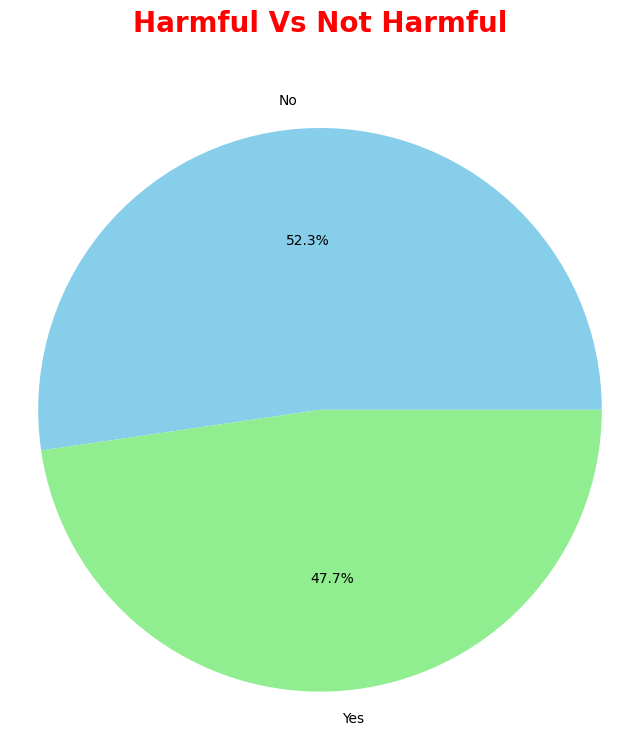

In [11]:
#percentage of harmful and not harmful bacteria in data
harmful_count = df["Harmful to Humans"].value_counts()

plt.figure(figsize = (8, 8))
plt.pie(harmful_count, labels = harmful_count.index, autopct = "%1.1f%%", colors = ["skyblue", "lightgreen"])
plt.title("Harmful Vs Not Harmful", fontsize = 20, color = "red", fontweight = "bold", y = 1.1)
plt.axis("equal")
plt.show()

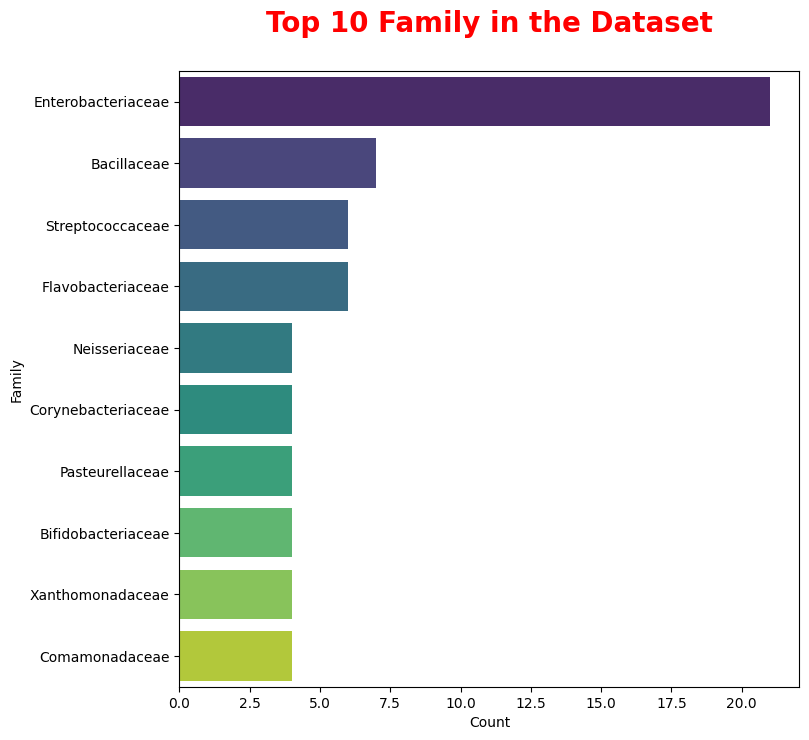

In [12]:
# top 10 families in data
family_counts = df["Family"].value_counts().head(10)

plt.figure(figsize = (8, 8))
sns.barplot(x = family_counts, y = family_counts.index, palette = "viridis")
plt.title("Top 10 Family in the Dataset", fontsize = 20, color = "red", fontweight = "bold", y = 1.05)
plt.xlabel("Count")
plt.ylabel("Family")
plt.show()

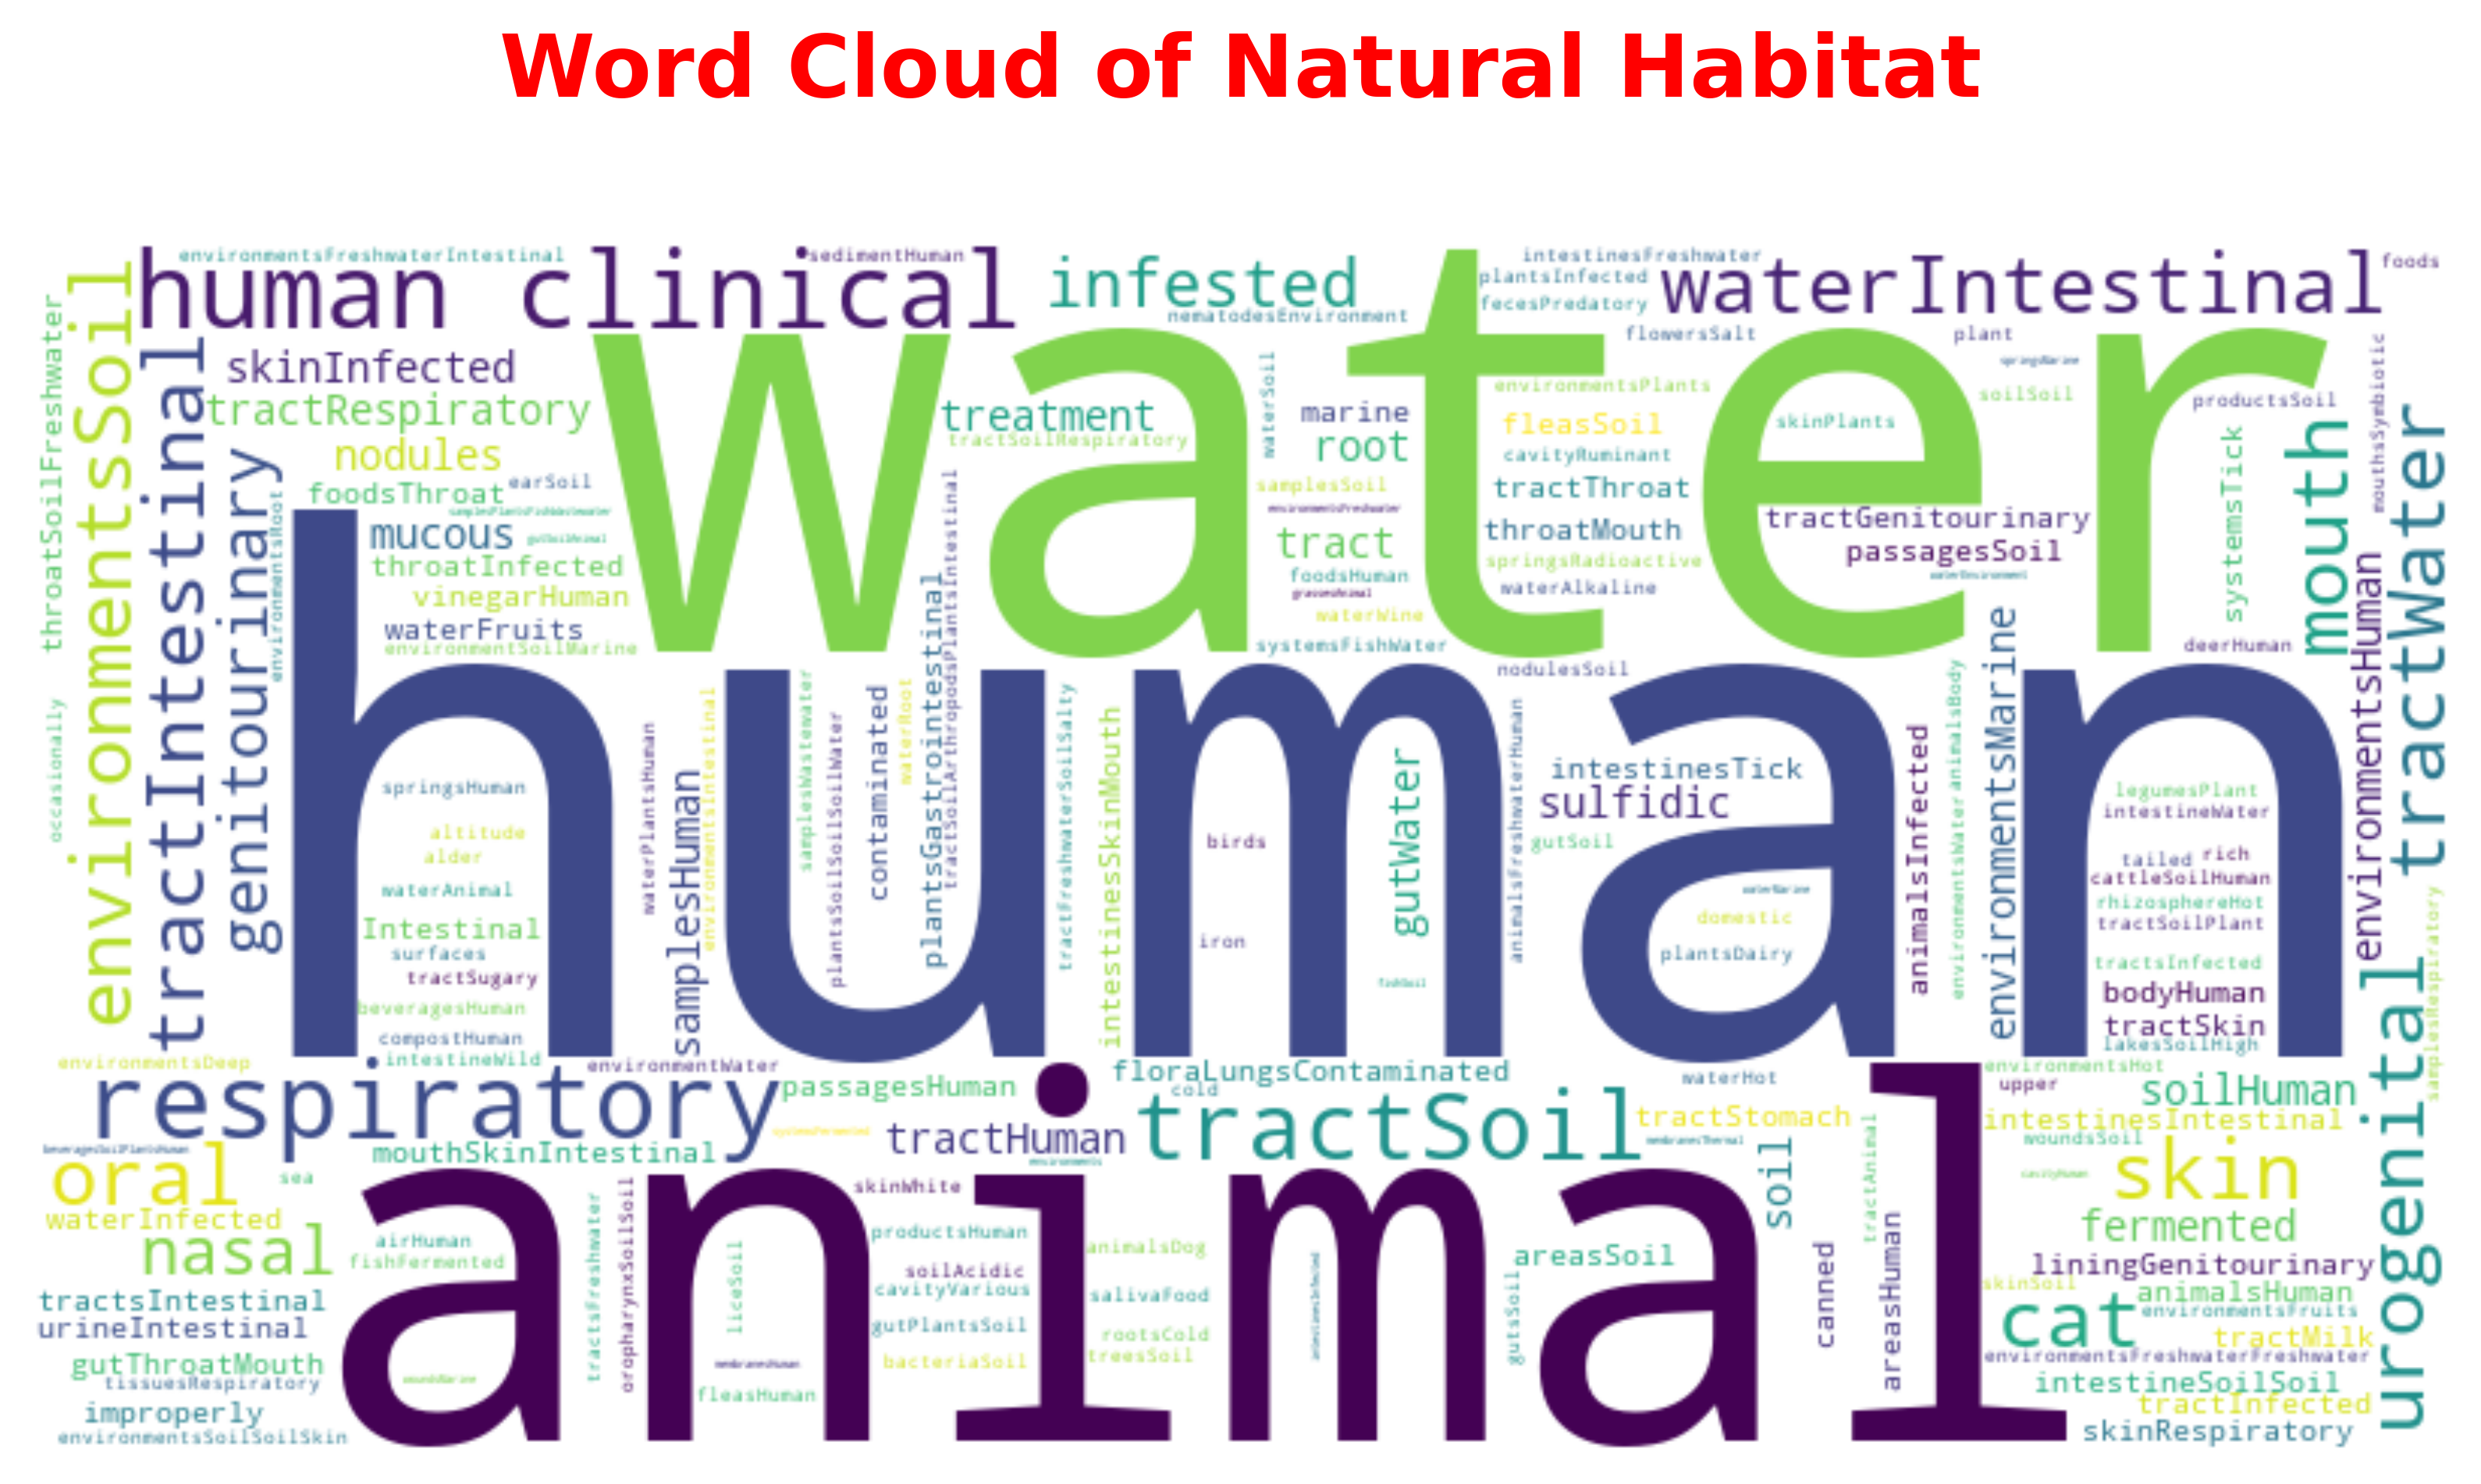

In [13]:
#The most common habitats for bacteria in the dataset
#Combine all Natural habitats into single string

habitat_text = "".join(df["Where Found"])

# Generate  a word cloud image

wordcloud = WordCloud(width = 800, height = 400, background_color = "white").generate(habitat_text)

# Plot the word cloud

plt.figure(figsize = (10, 6), dpi=400)
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.title("Word Cloud of Natural Habitat", fontsize = 20, color = "red", fontweight = "bold", y = 1.1)
plt.show()


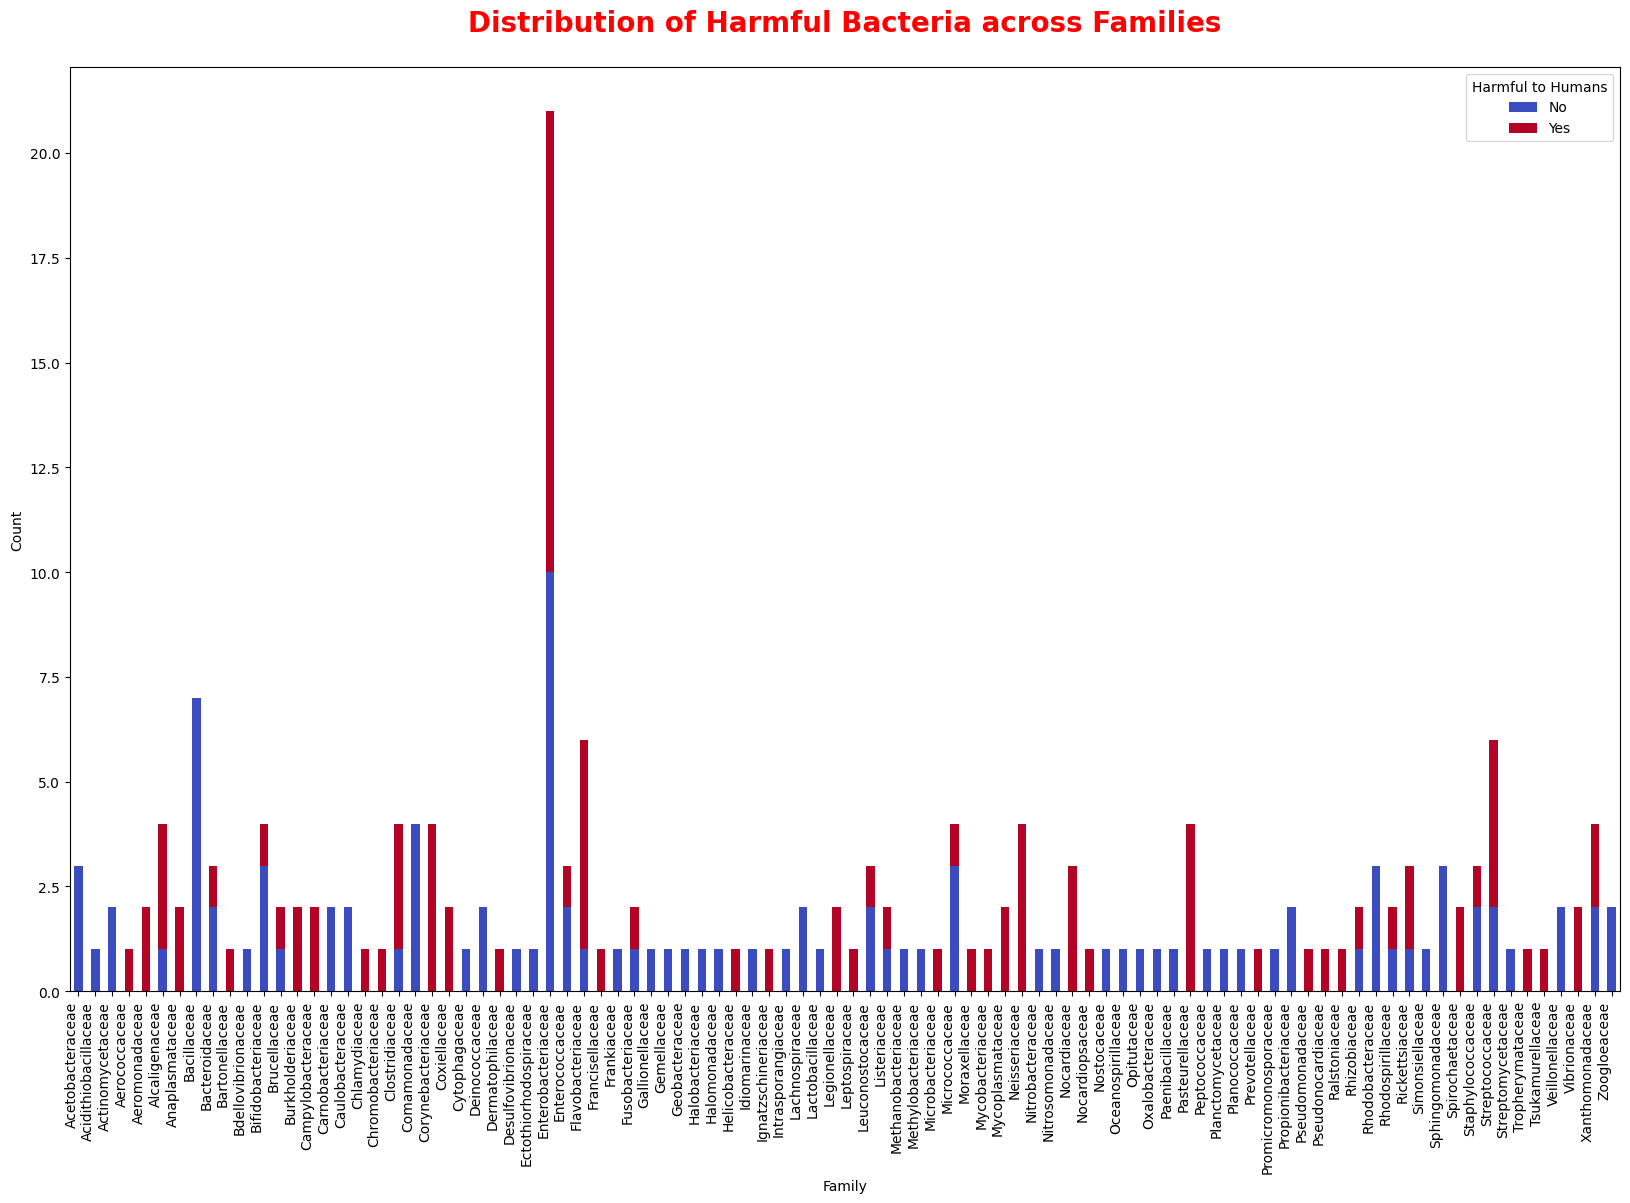

In [14]:
# Create a Stacked Bar Chart

stacked_data = df.groupby(["Family", "Harmful to Humans"]).size().unstack()
stacked_data.plot(kind = "bar", stacked = True, figsize = (20, 12), colormap = "coolwarm")
plt.title("Distribution of Harmful Bacteria across Families", fontsize = 20, color = "red", fontweight = "bold", y = 1.03)
plt.xlabel("Family")
plt.ylabel("Count")
plt.xticks(rotation = 90, ha = "right")
plt.legend(title = "Harmful to Humans", loc = "upper right")
plt.show()


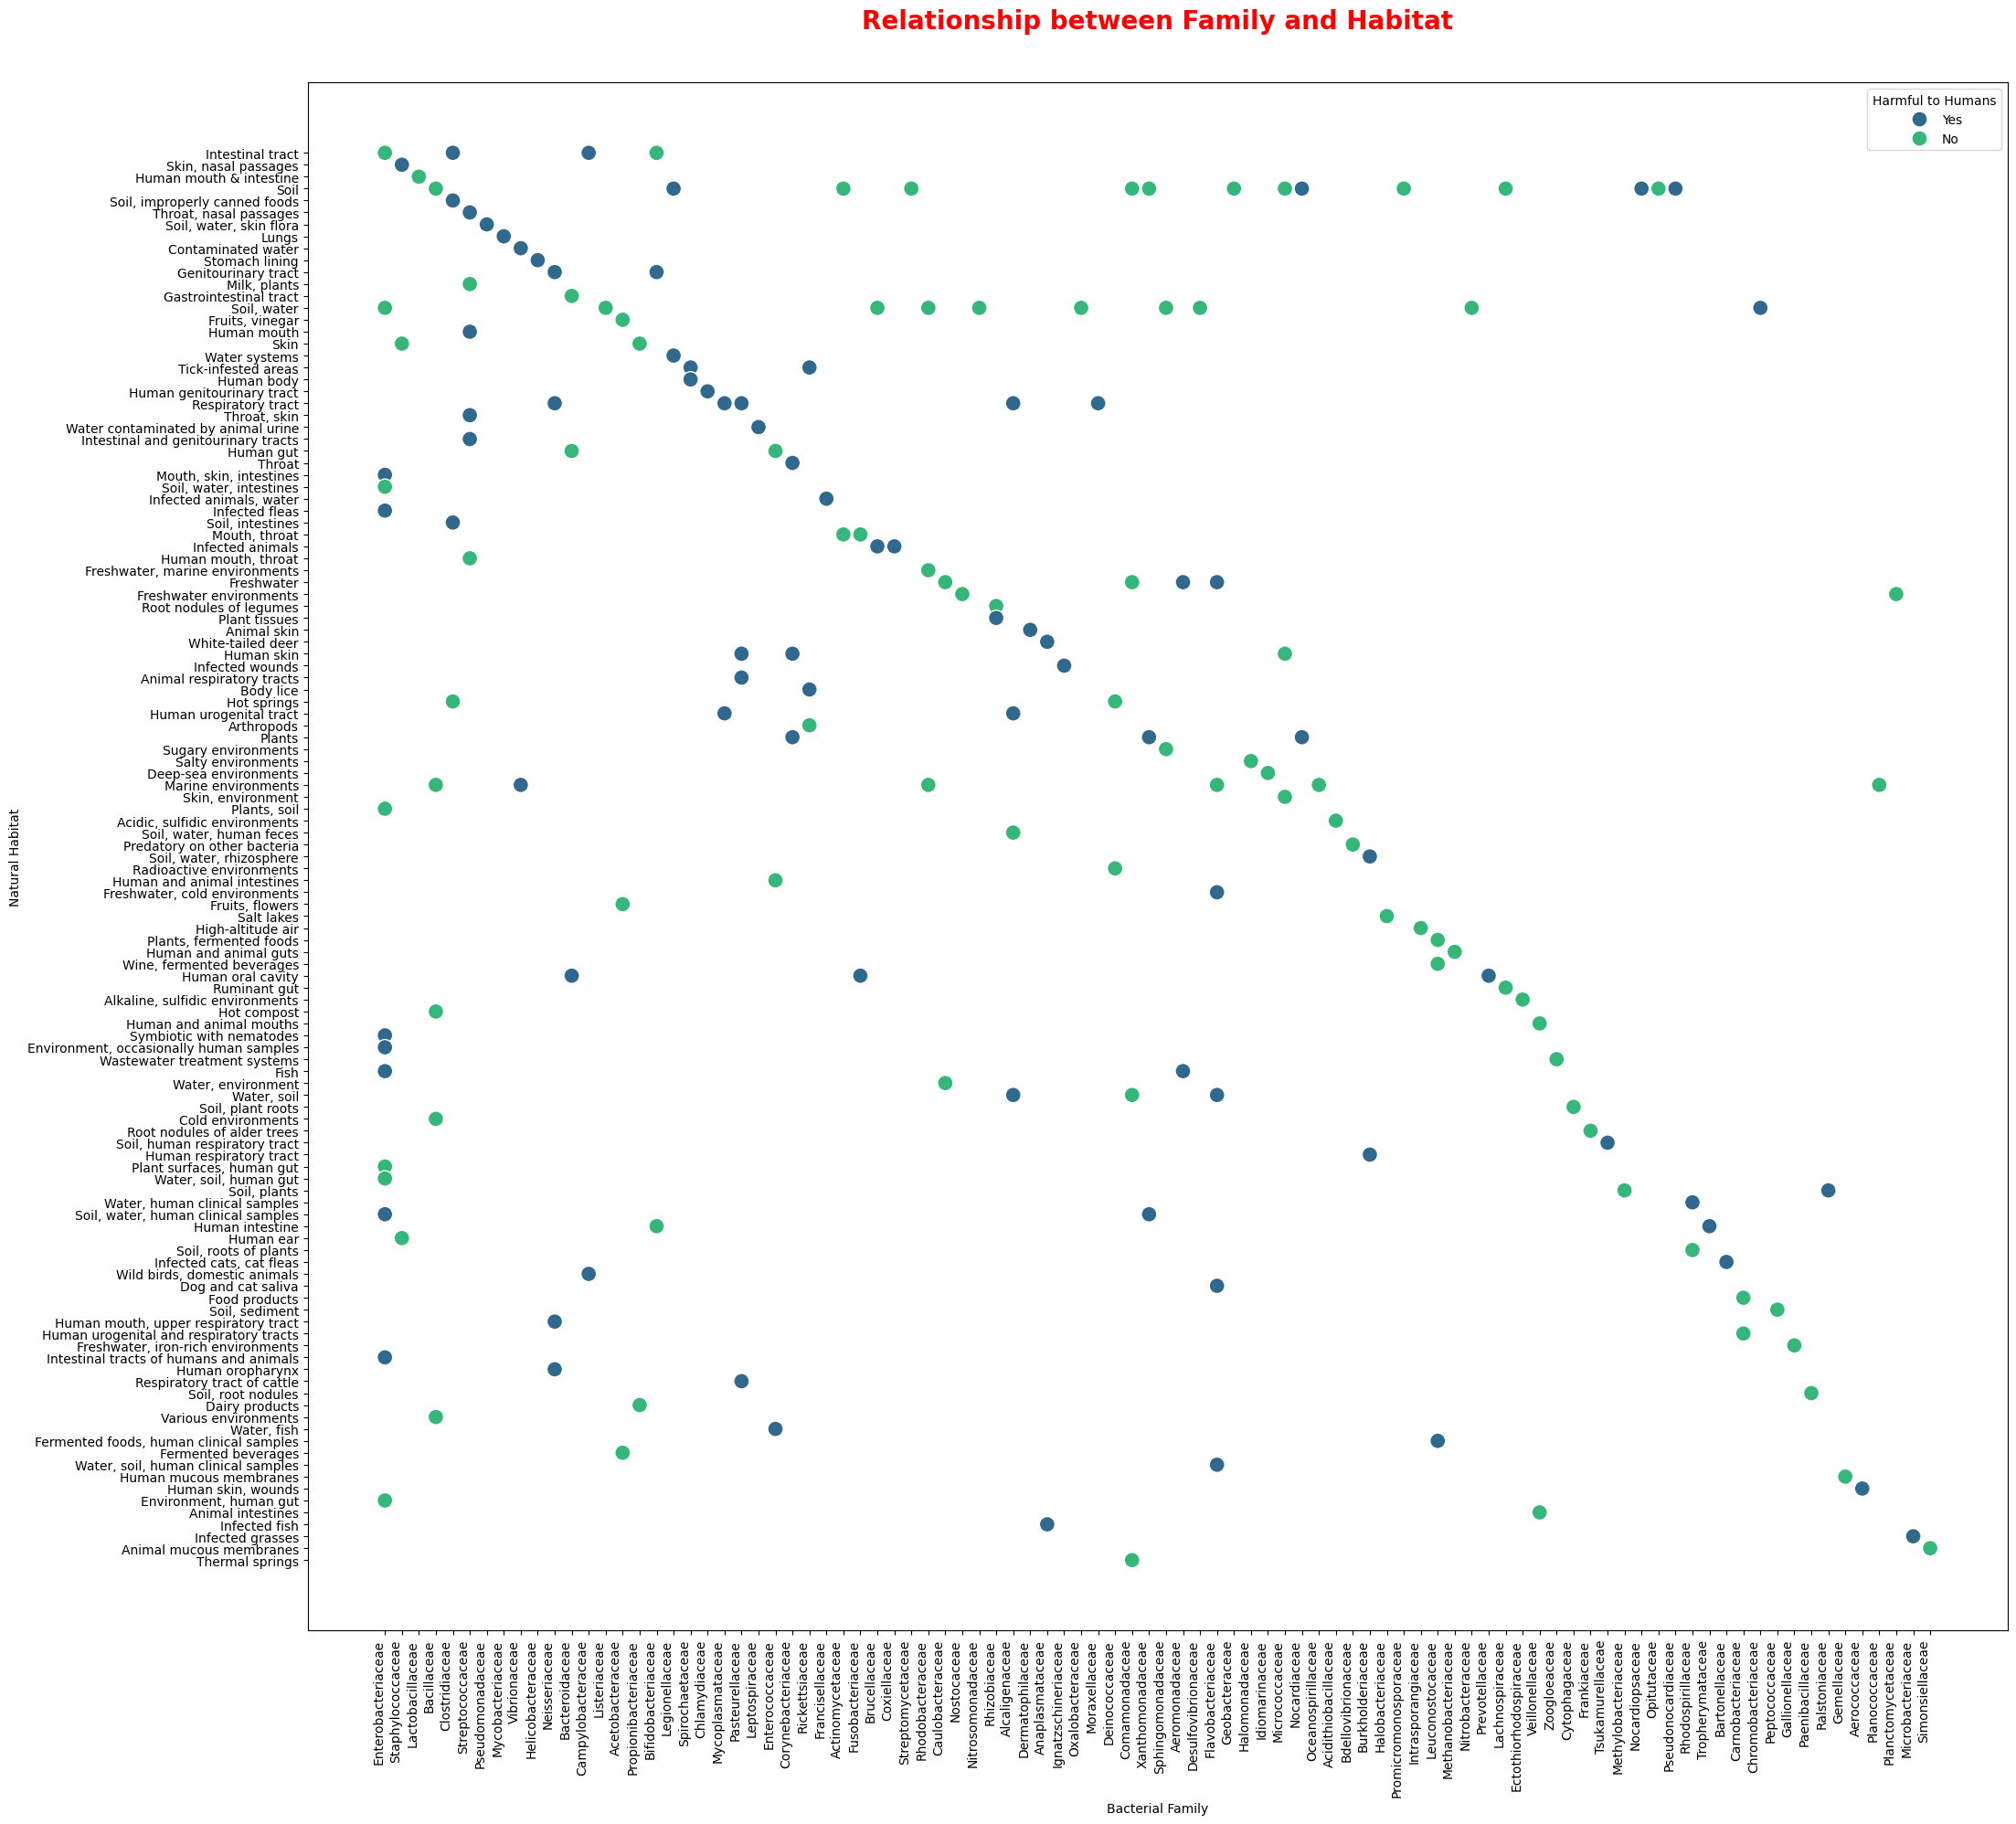

In [15]:
# Create a Scatter PLot

plt.figure(figsize = (24, 22))
sns.scatterplot(x = "Family", y = "Where Found", hue = "Harmful to Humans", data = df, palette = "viridis", s=150, alpha=1)
plt.title("Relationship between Family and Habitat", fontsize = 20, color = "red", fontweight = "bold", y = 1.03)
plt.xlabel("Bacterial Family")
plt.ylabel("Natural Habitat")
plt.xticks(rotation = 90, ha = "right")
plt.legend(title = "Harmful to Humans", loc = "upper right")
plt.show()


The count of full dangerous families of bacteria on human health in the dataset 32
Number of full dangerous families with more than one occurance in the dataset: 13


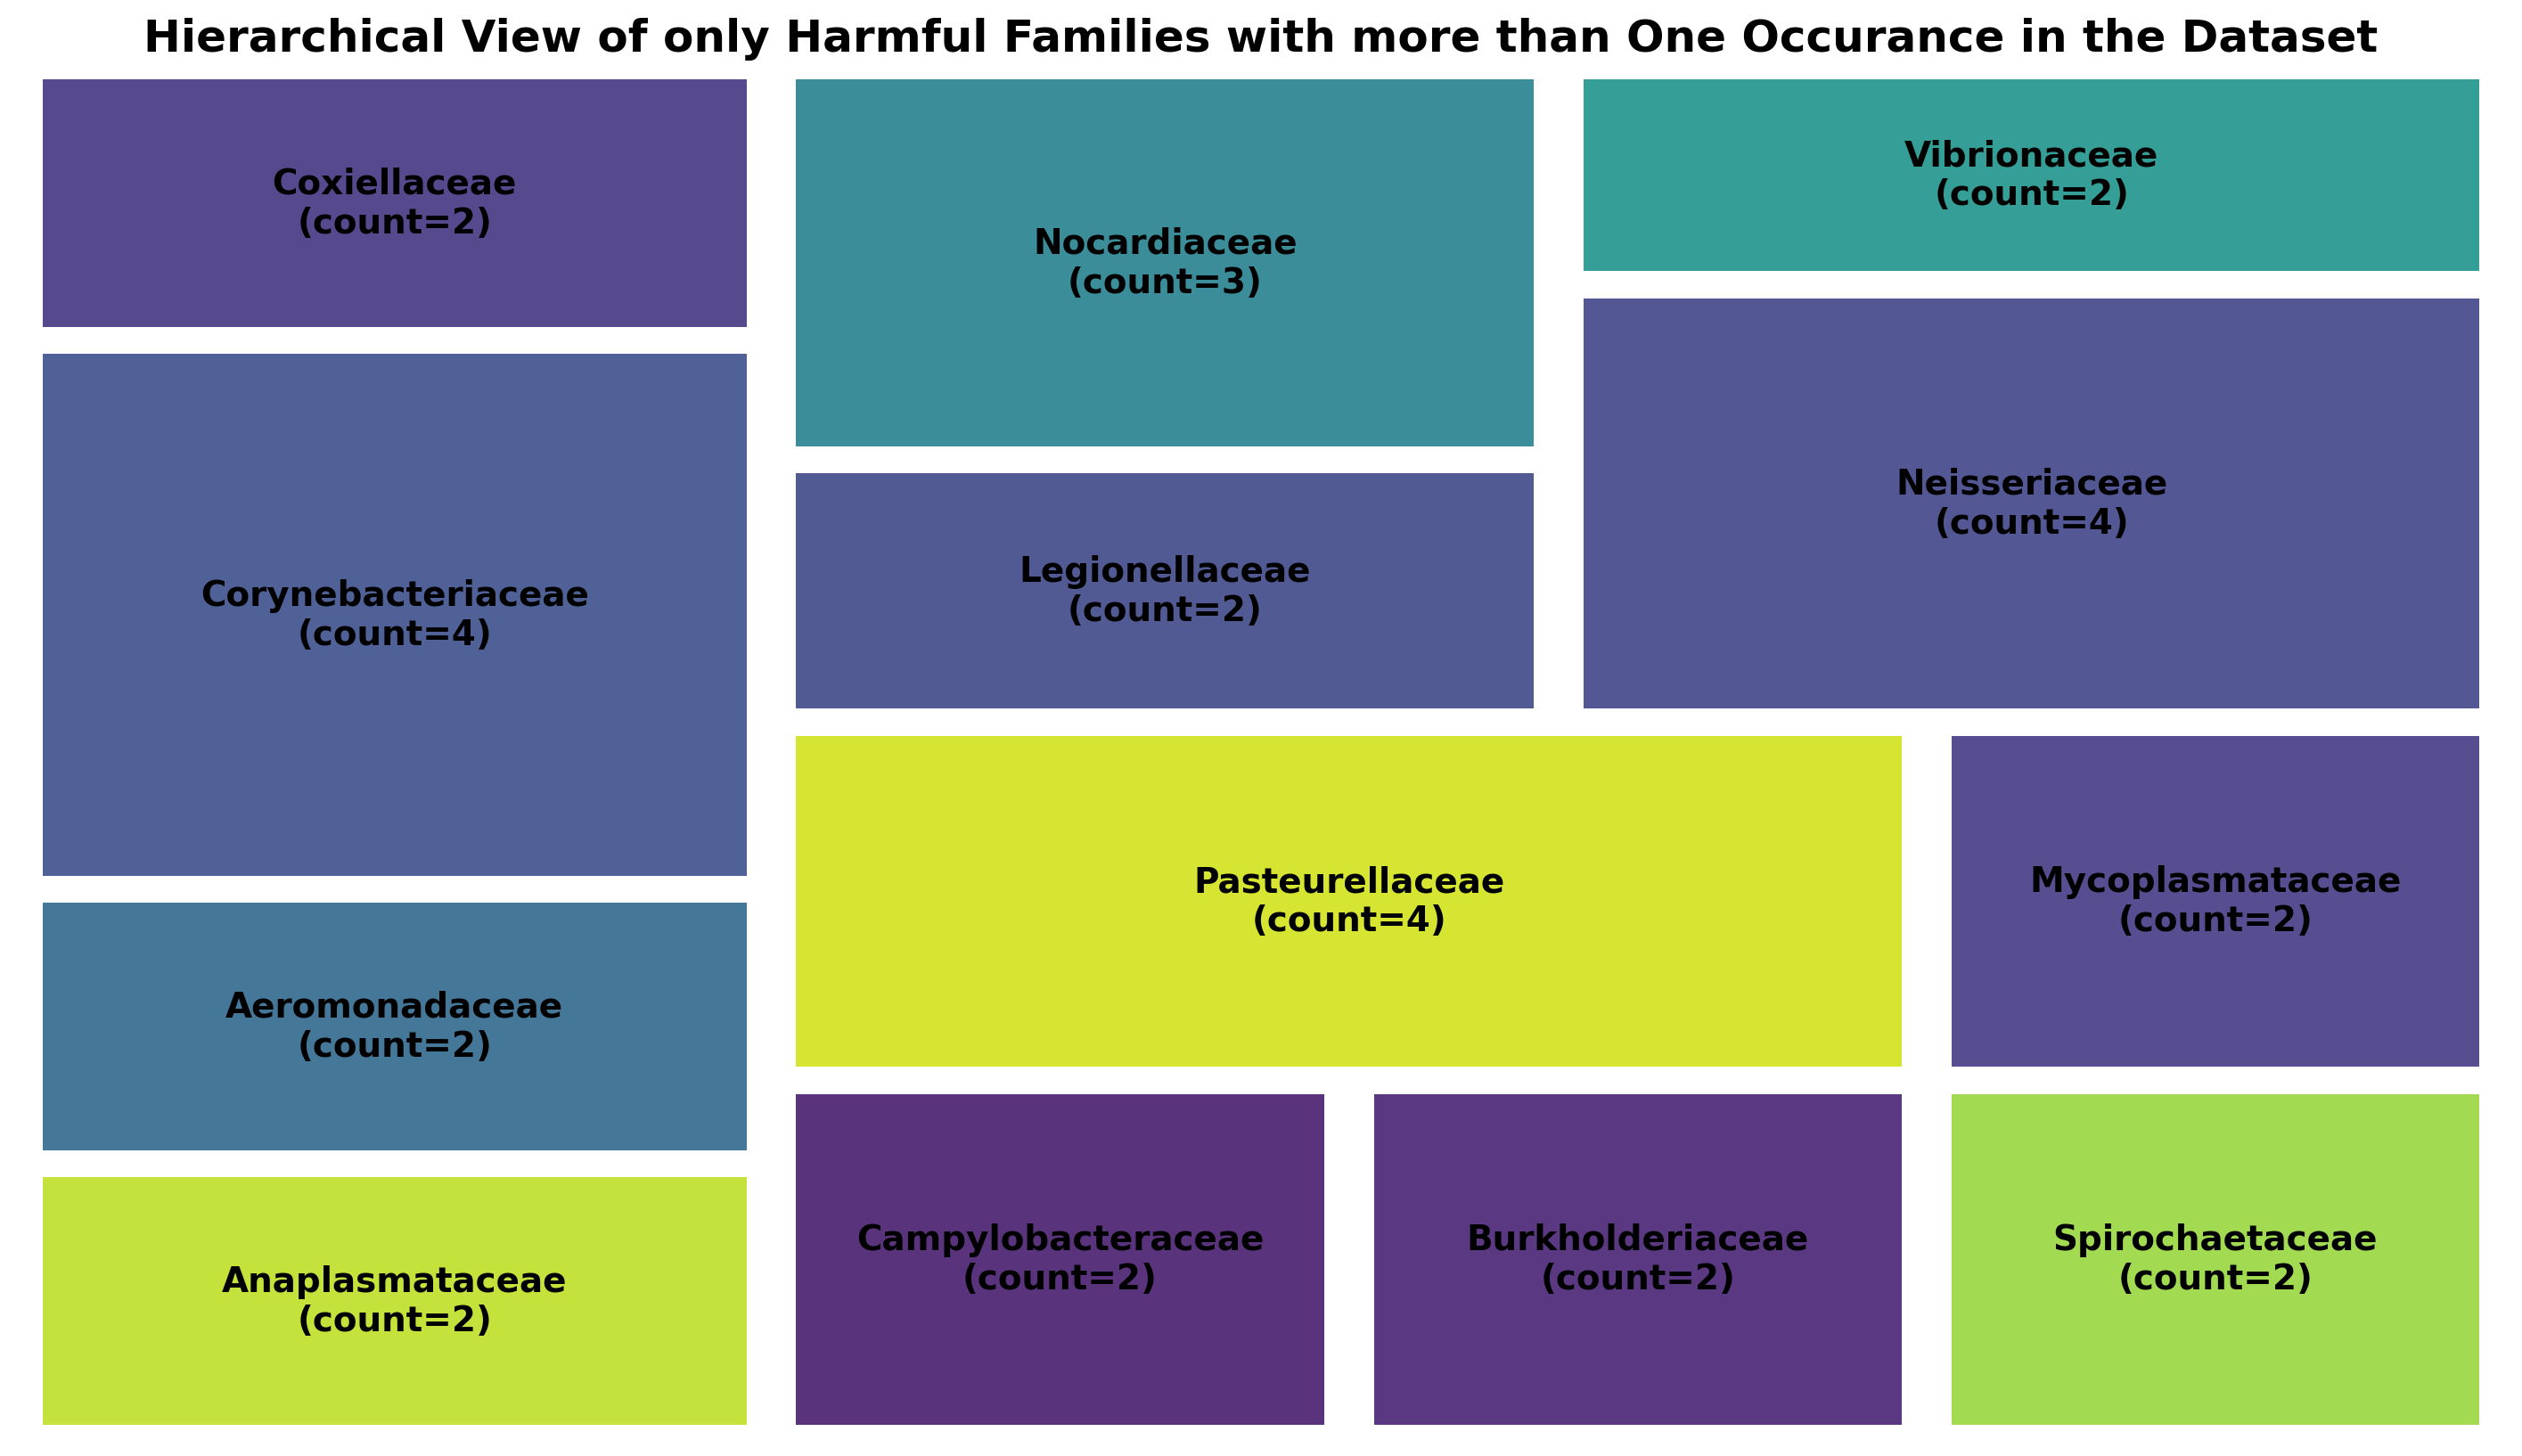

In [16]:
#the most dangerous families of bacteria on human health
family_stats = df.groupby('Family').agg(
    total=('Harmful to Humans', 'count'),
    harmful=('Harmful to Humans', lambda x: (x == 'Yes').sum())
)

family_stats['percentage'] = family_stats['harmful'] / family_stats['total']

family_stats_sorted = family_stats.sort_values(by='percentage', ascending=False)
family_stats_sorted = family_stats_sorted.reset_index()
family_full_dangerous = family_stats_sorted[family_stats_sorted['percentage'] == 1]
print('The count of full dangerous families of bacteria on human health in the dataset', family_full_dangerous.shape[0])

# select ones with more than one occurance in the dataset
family_full_dangerous = family_full_dangerous[family_full_dangerous['total'] > 1]
print("Number of full dangerous families with more than one occurance in the dataset:", family_full_dangerous.shape[0])

# Create labels
labels = family_full_dangerous.apply(
    lambda x: f"{x['Family']}\n(count={x['total']})",
    axis=1
)

# Plot
plt.figure(figsize=(18, 10), dpi=200)

squarify.plot(
    sizes=family_full_dangerous["total"],
    label=labels,
    alpha=0.9,
    text_kwargs={"fontsize": 14, "fontweight": "bold"},
    pad=True
)

plt.axis("off")
plt.title(
    "Hierarchical View of only Harmful Families with more than One Occurance in the Dataset",
    fontsize=18,
    fontweight="bold"
)

plt.show()

The count of families of bacteria with no danger on human health in the dataset 42
Number of full dangerous families with more than one occurance in the dataset: 13


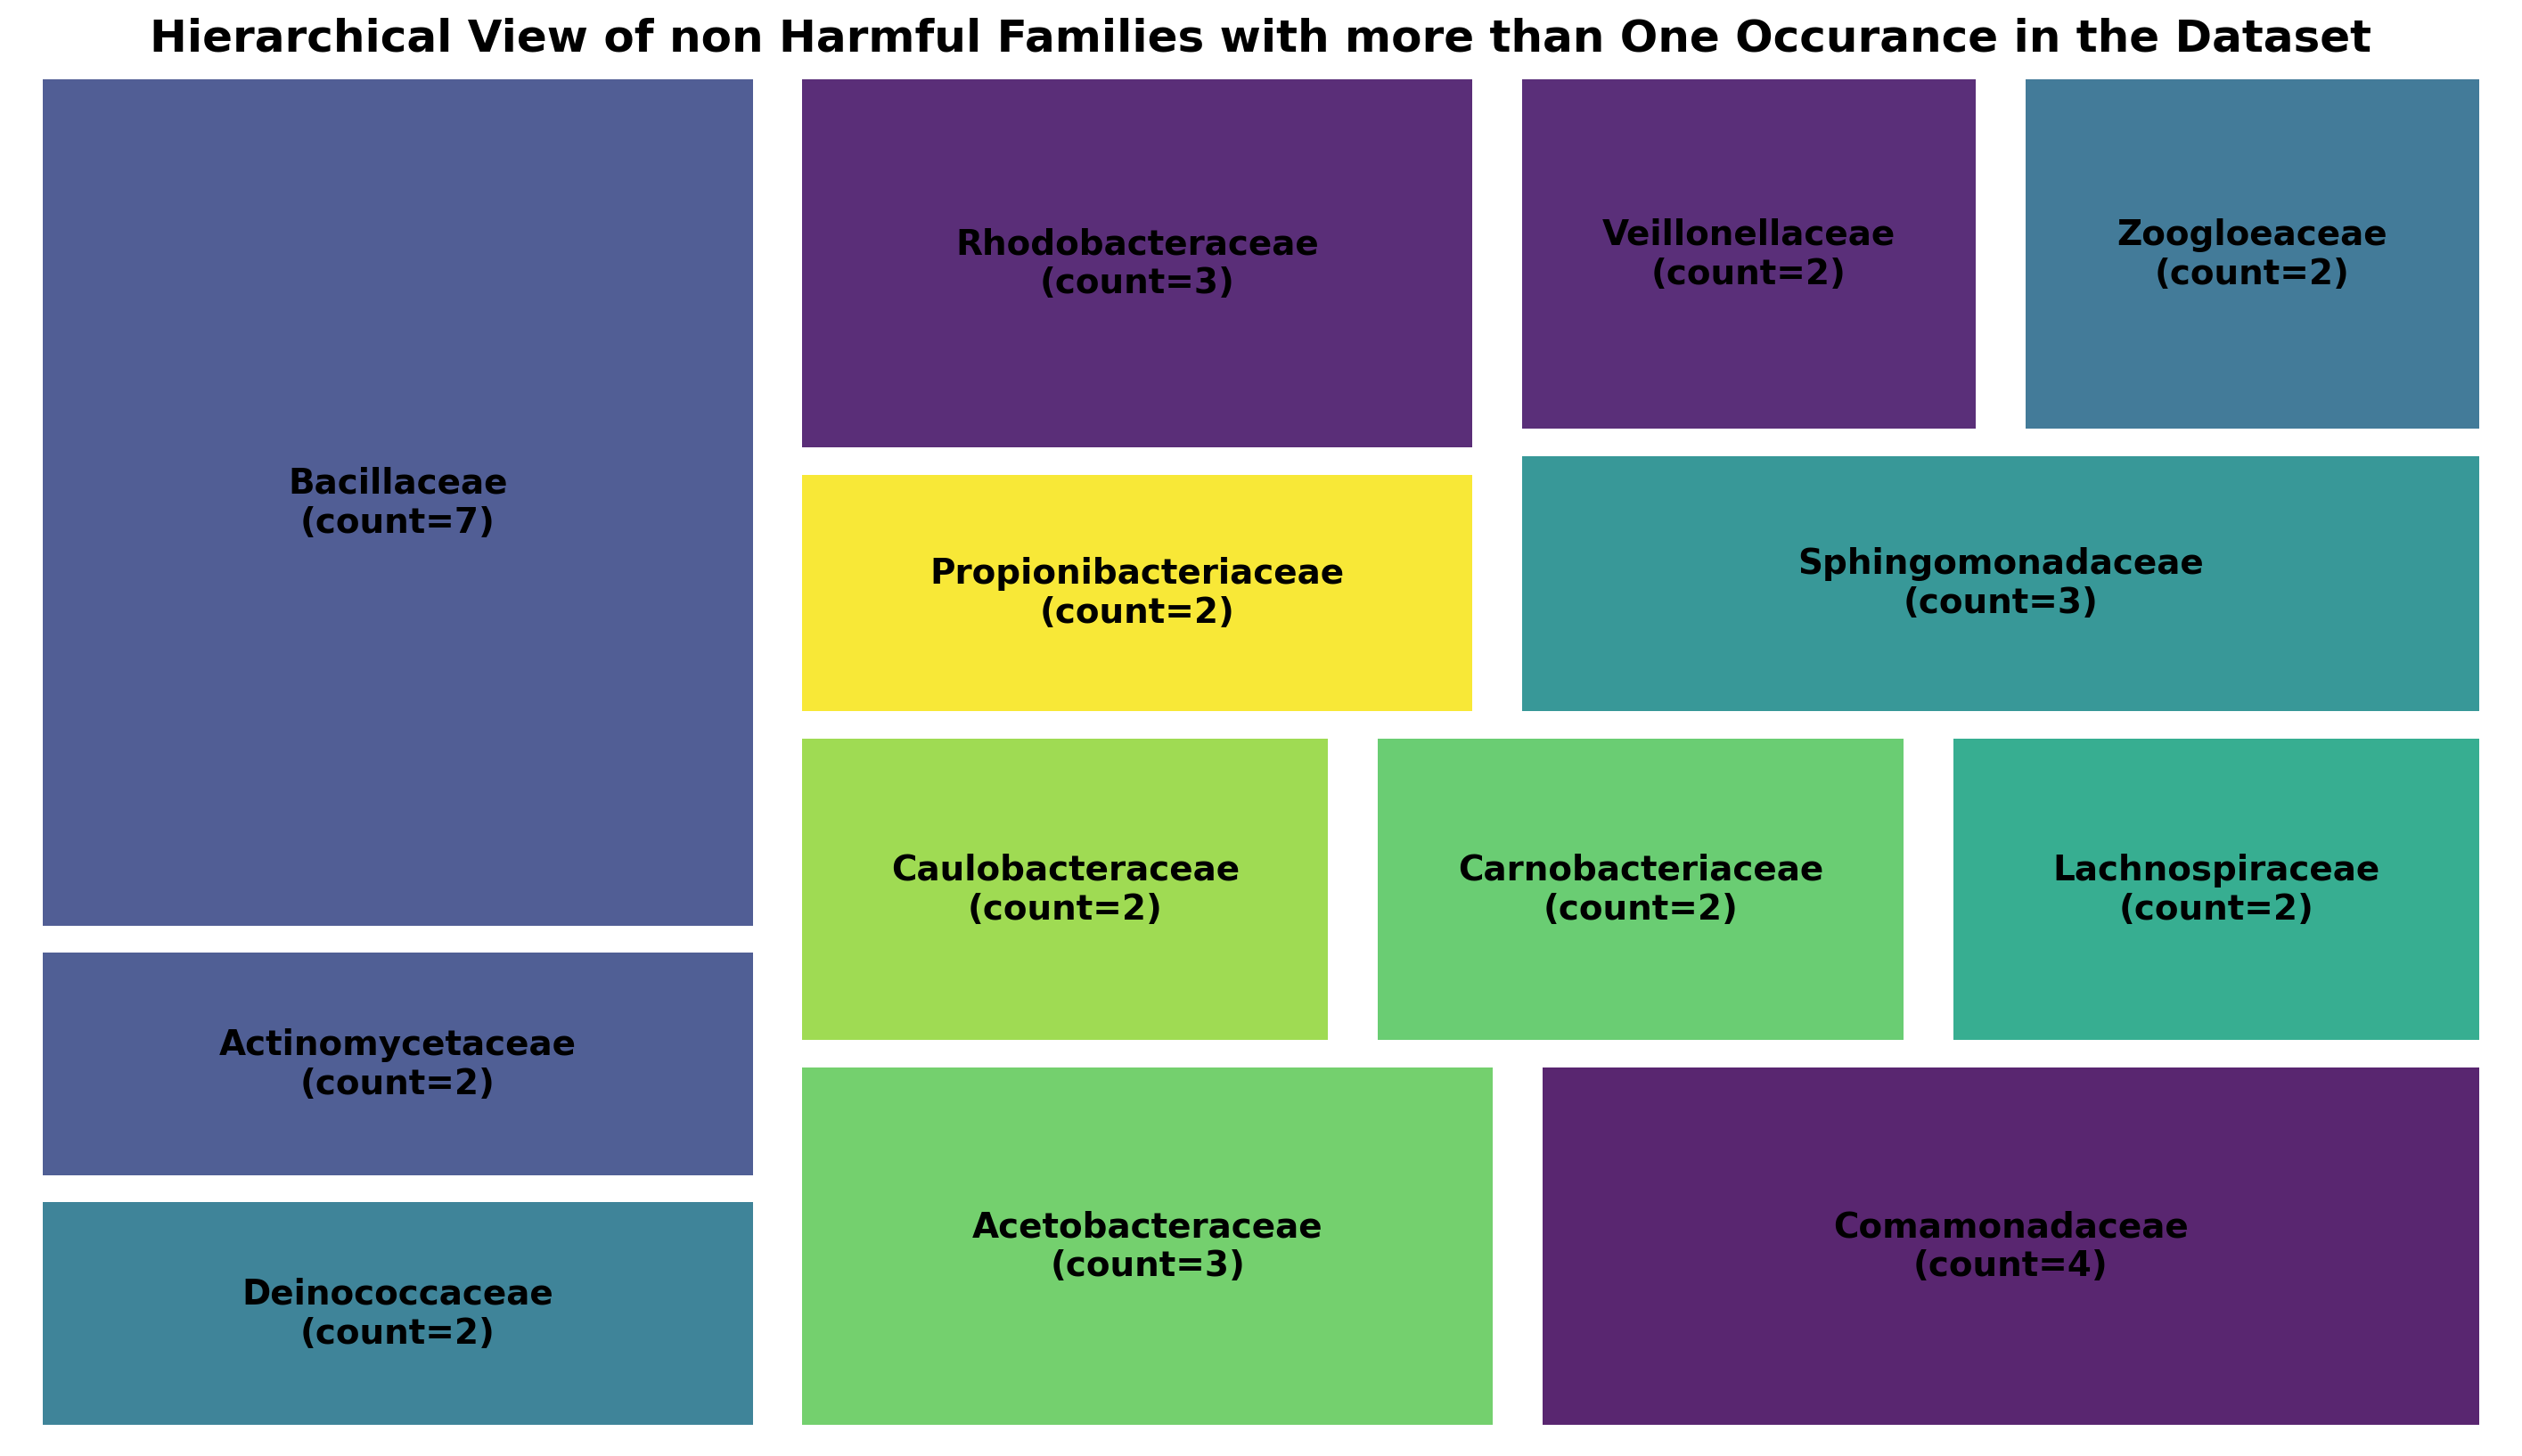

In [17]:
#families of bacteria with no danger on human health in dataset
family_no_danger = family_stats_sorted[family_stats_sorted['percentage'] == 0]
print('The count of families of bacteria with no danger on human health in the dataset', family_no_danger.shape[0])

# select ones with more than one occurance in the dataset
family_no_danger = family_no_danger[family_no_danger['total'] > 1]
print("Number of full dangerous families with more than one occurance in the dataset:", family_no_danger.shape[0])

# Create labels
labels = family_no_danger.apply(
    lambda x: f"{x['Family']}\n(count={x['total']})",
    axis=1
)

# Plot
plt.figure(figsize=(18, 10), dpi=200)

squarify.plot(
    sizes=family_no_danger["total"],
    label=labels,
    alpha=0.9,
    text_kwargs={"fontsize": 14, "fontweight": "bold"},
    pad=True
)

plt.axis("off")
plt.title(
    "Hierarchical View of non Harmful Families with more than One Occurance in the Dataset",
    fontsize=18,
    fontweight="bold"
)

plt.show()

Number of partially harmful bacterial families: 18


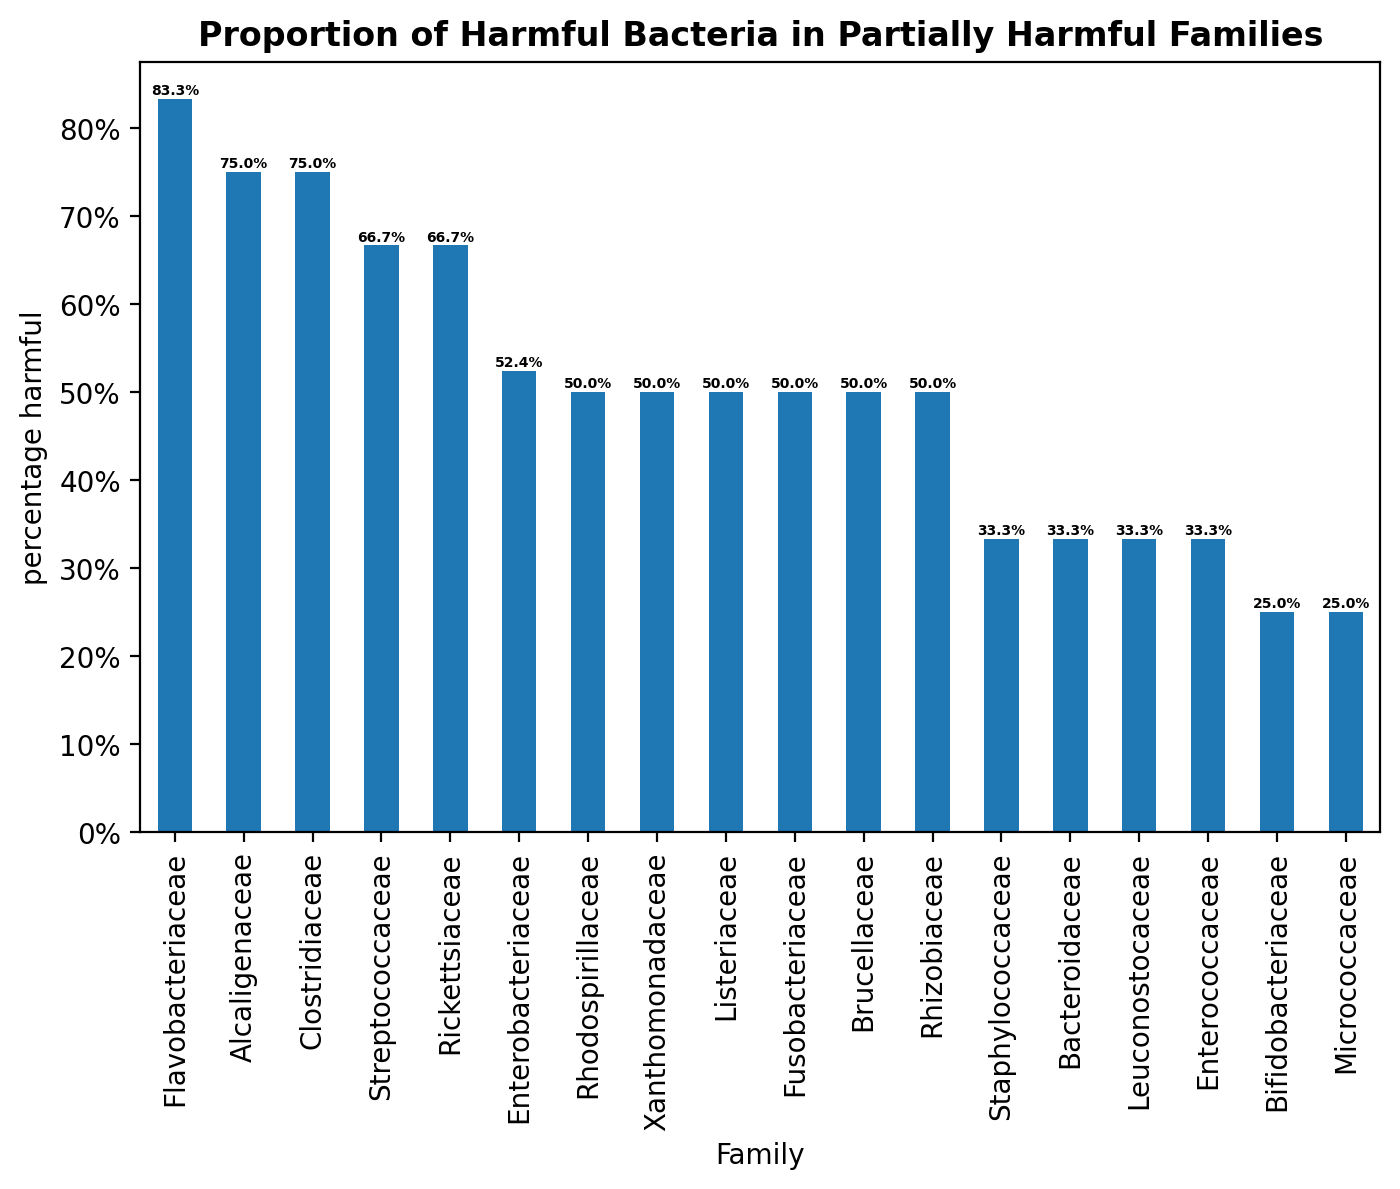

In [18]:
#families with partial danger on human health in the dataset
families_middle_danger = family_stats_sorted[(family_stats_sorted['percentage'] > 0) & (family_stats_sorted['percentage'] < 1)]
families_middle_danger = families_middle_danger.set_index('Family')
fig, ax=plt.subplots(figsize=(8, 5), dpi=200)
families_middle_danger['percentage'].plot.bar(ax=ax)
ax.set_ylabel('percentage harmful')
ax.set_yticklabels(['{:.0f}%'.format(x*100) for x in ax.get_yticks()]); 
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.1%}",
        ha='center',
        fontweight='bold',
        fontsize=5
    );
ax.set_title('Proportion of Harmful Bacteria in Partially Harmful Families', fontweight='bold')
print('Number of partially harmful bacterial families:', families_middle_danger.shape[0])

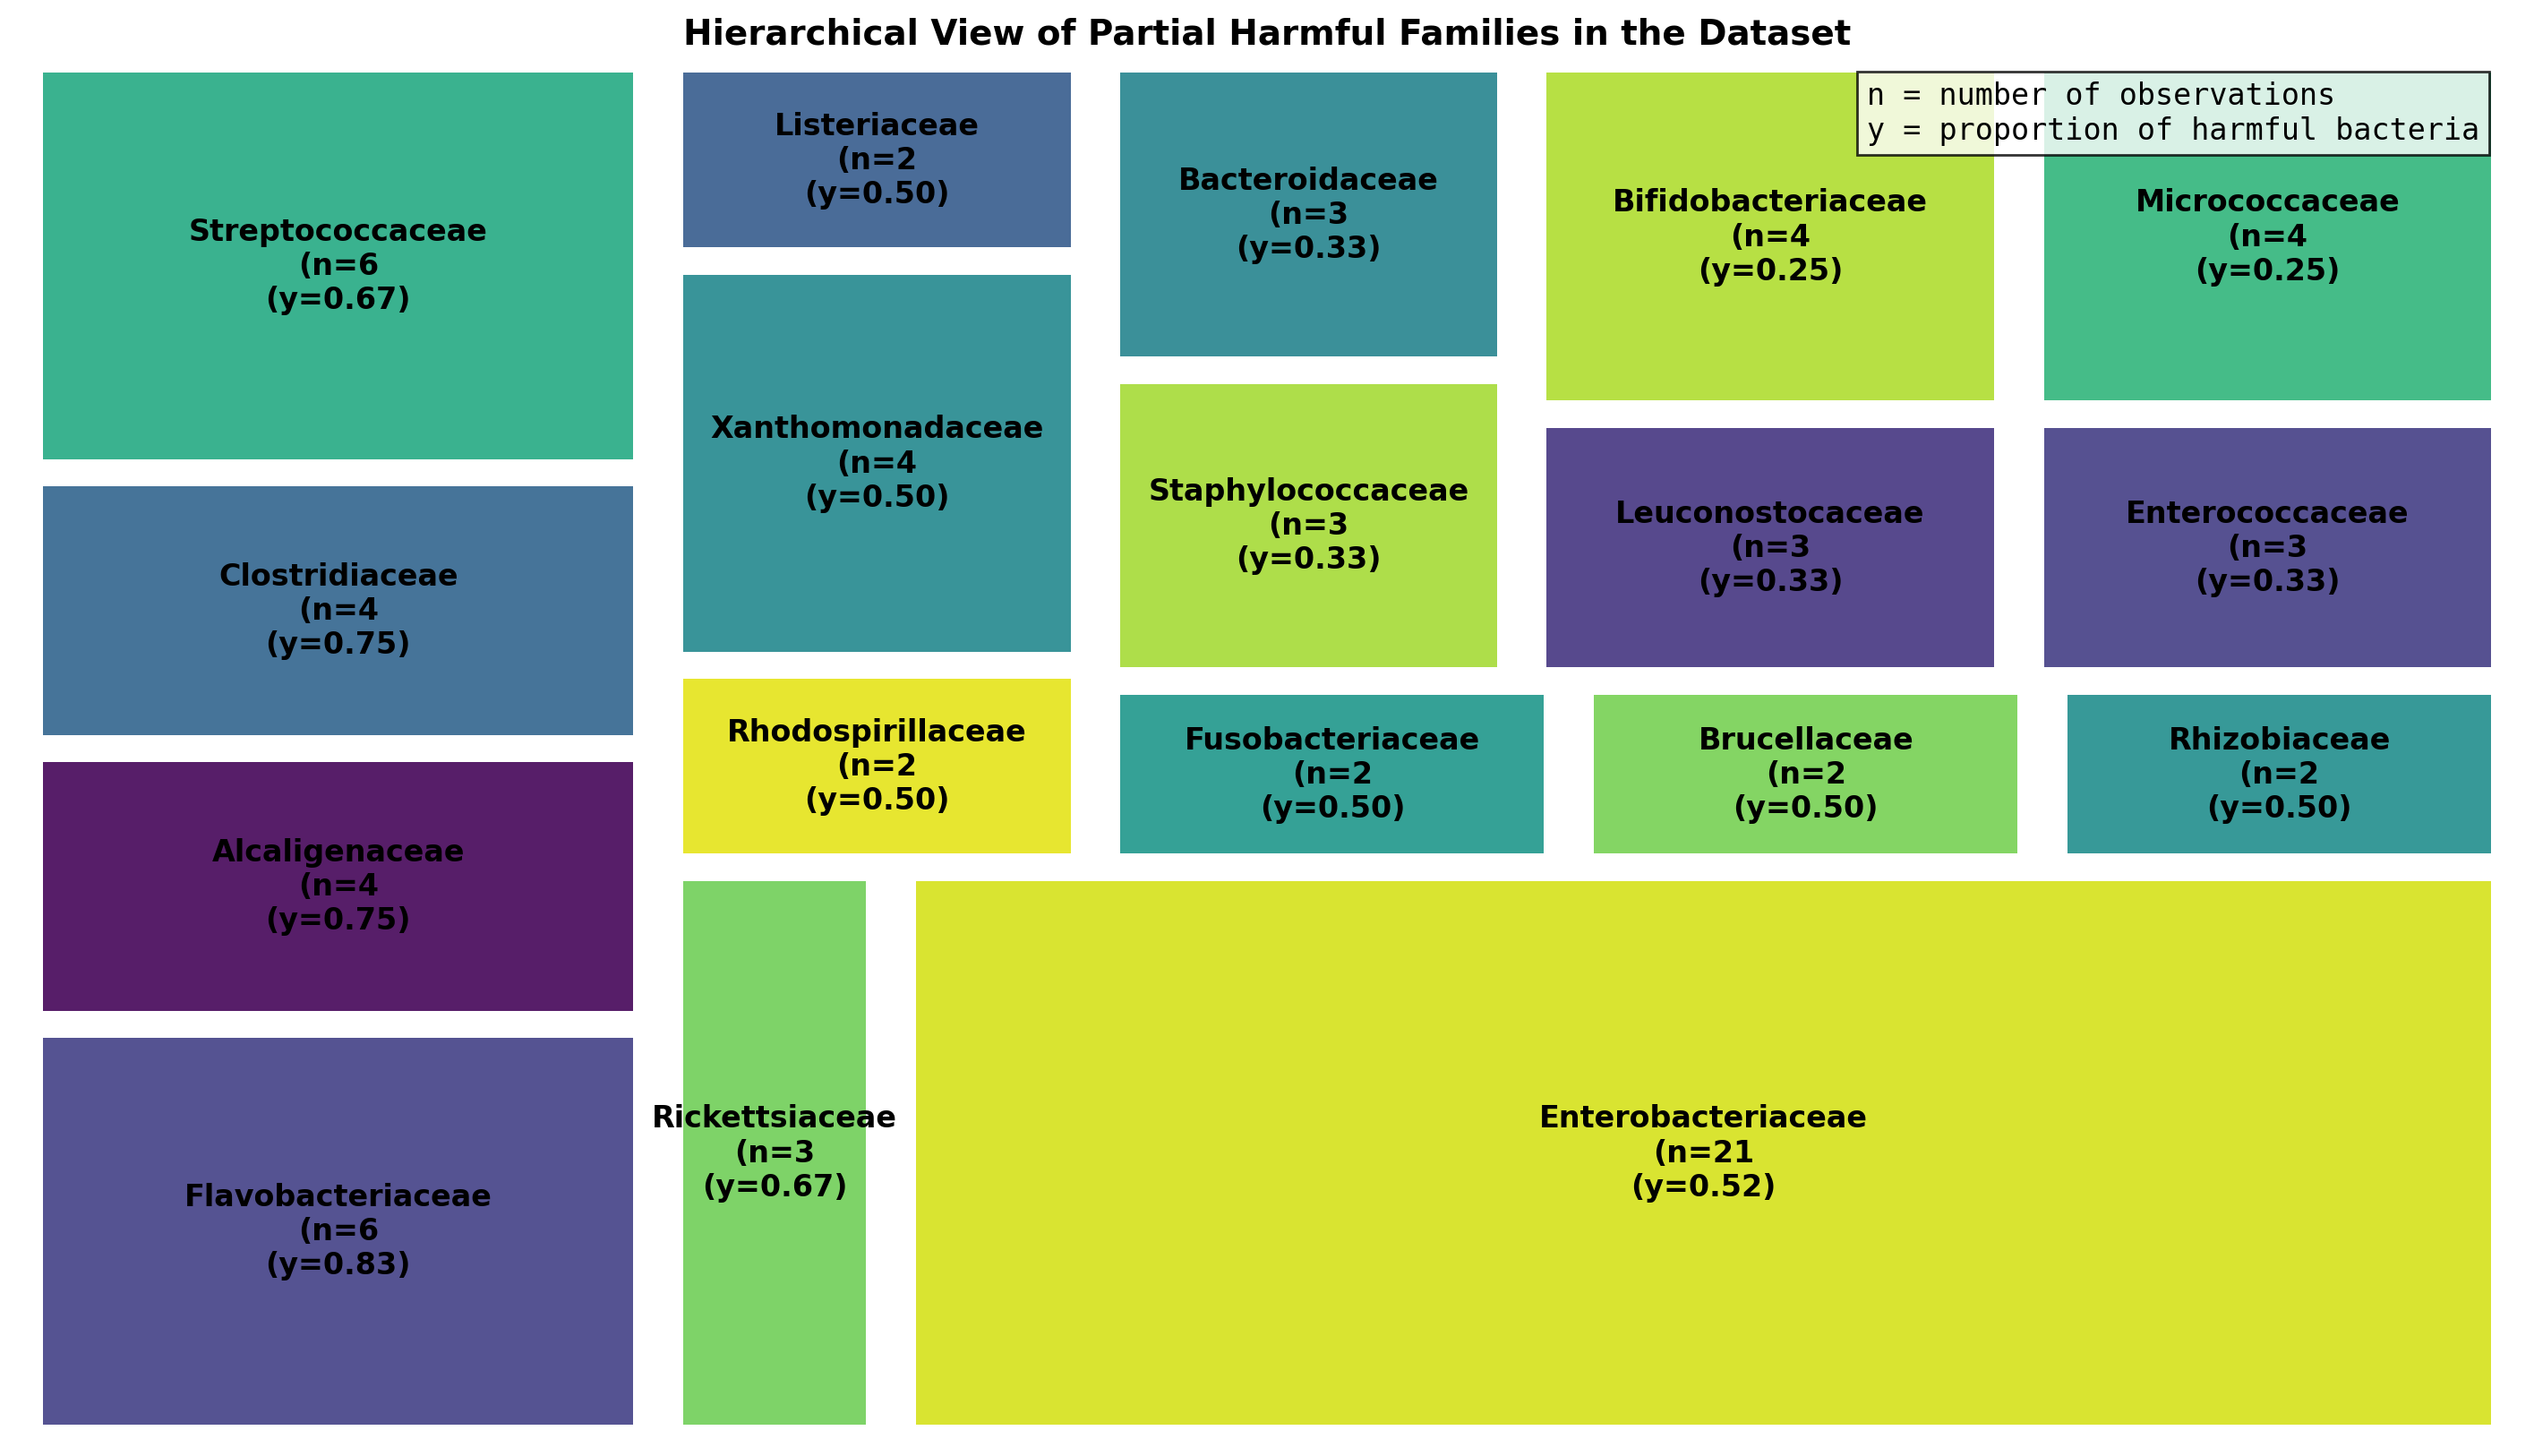

In [19]:
#habitats for partial harmful bacteria on the human health with more than one occurance in the dataset
# Filter partial harmful habitats
families_middle_danger = families_middle_danger.reset_index()

# Create labels
labels = families_middle_danger.apply(
    lambda x: f"{x['Family']}\n(n={x['total']}\n(y={x['percentage']:.2f})",
    axis=1
)

# Plot
plt.figure(figsize=(18, 10), dpi=200)

squarify.plot(
    sizes=families_middle_danger["total"],
    label=labels,
    alpha=0.9,
    text_kwargs={"fontsize": 12, "fontweight": "bold"},
    pad=True
)

plt.axis("off")
plt.title(
    "Hierarchical View of Partial Harmful Families in the Dataset",
    fontsize=14,
    fontweight="bold"
)
plt.text(
    0.74, 0.984,
    "n = number of observations\n"
    "y = proportion of harmful bacteria",
    ha='left',
    va='top',
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.8),
    transform=plt.gca().transAxes,
    family='monospace'
)
plt.show()

In [20]:
#the relationship between habitat and the proportion of harmful bacteria
habitat_stats = df.groupby(['Where Found']).agg(
    total=('Harmful to Humans', 'count'),
    harmful=('Harmful to Humans', lambda x: (x == 'Yes').sum())
)

habitat_stats['percentage'] = habitat_stats['harmful'] / habitat_stats['total']
habitat_stats.reset_index()

habitat_stats_sorted = habitat_stats.sort_values(by='percentage', ascending=False)
habitat_stats_sorted = habitat_stats_sorted.reset_index()
habitat_stats_sorted

,Where Found,total,harmful,percentage
0,Animal respiratory tracts,1,1,1.0
1,Animal skin,1,1,1.0
2,Fish,2,2,1.0
3,Dog and cat saliva,1,1,1.0
4,"Environment, occasionally human samples",1,1,1.0
...,...,...,...,...
114,Various environments,1,0,0.0
115,"Water, environment",1,0,0.0
116,Wastewater treatment systems,2,0,0.0
117,"Water, soil, human gut",1,0,0.0


Number of fully harmful habitats with more than one occurance in the dataset: 8


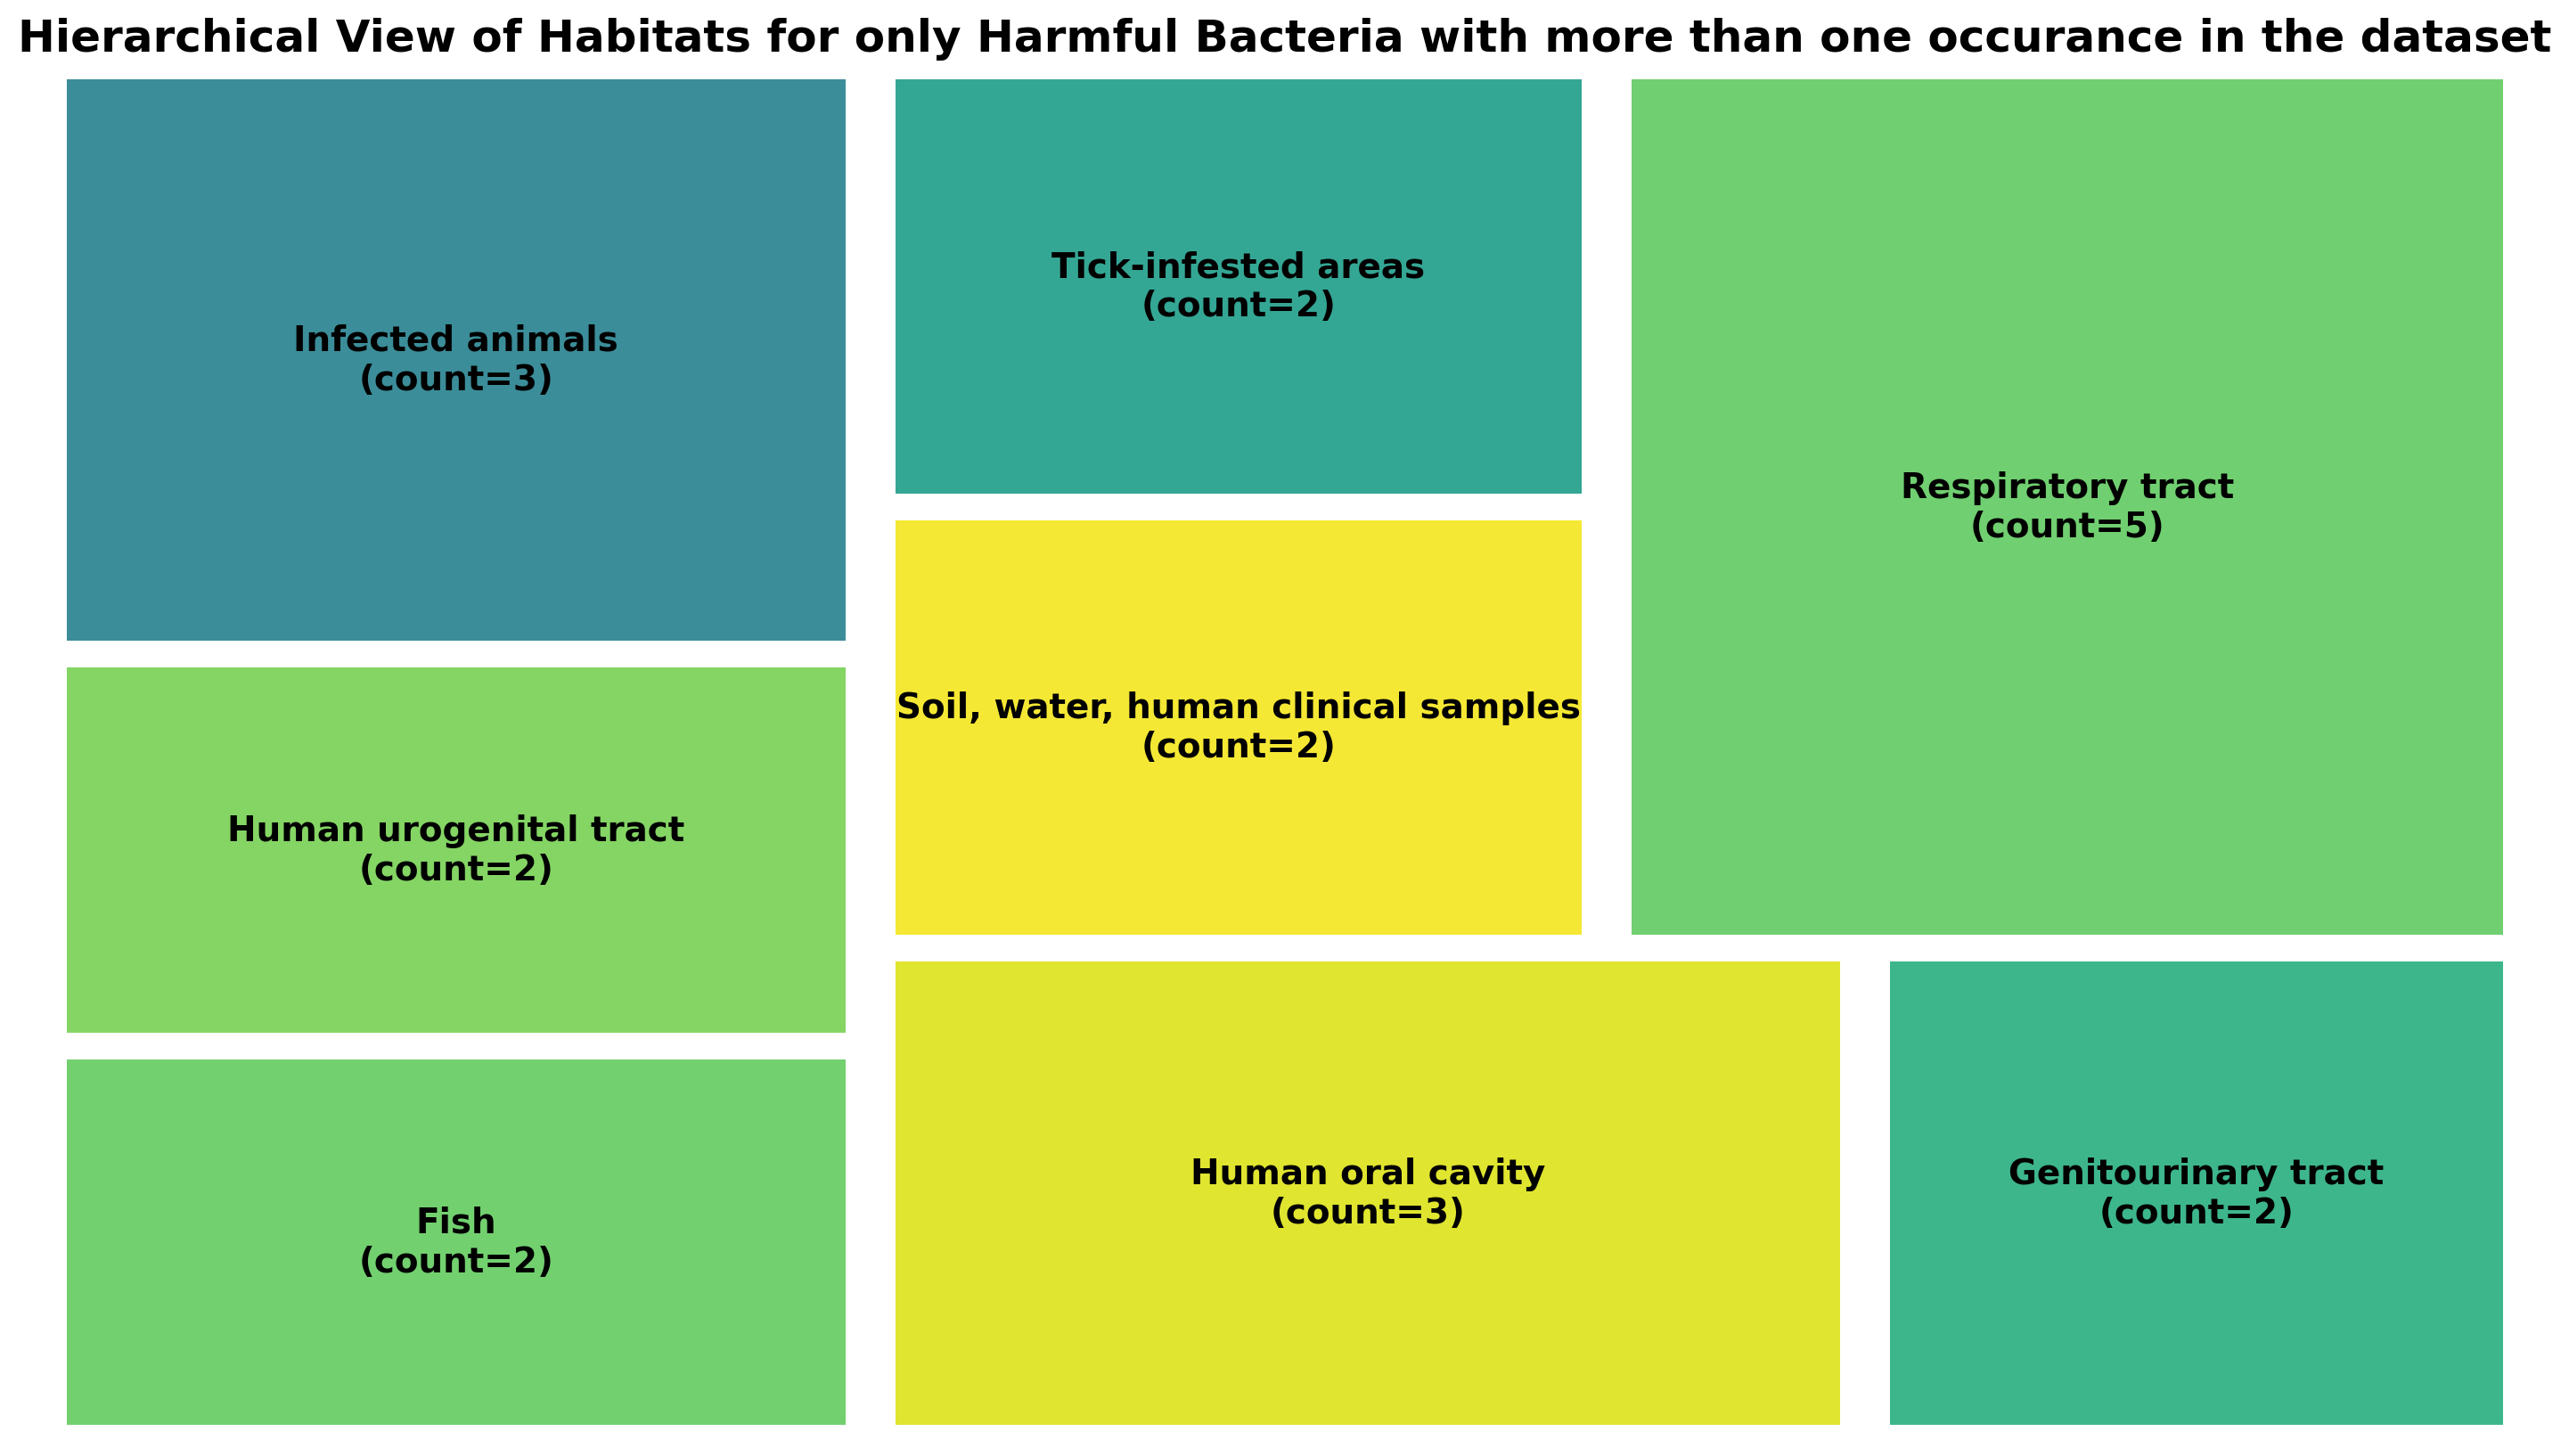

In [21]:
#habitats for exclusively full harmful bacteria
# Filter habitats for full harmful bacteria
habitat_stats_full_risk = habitat_stats_sorted[habitat_stats_sorted['percentage'] == 1]

# select ones with more than one occurance in the dataset
habitat_stats_full_risk = habitat_stats_full_risk[habitat_stats_full_risk['total'] > 1]
print("Number of fully harmful habitats with more than one occurance in the dataset:", habitat_stats_full_risk.shape[0])

# Create labels
labels = habitat_stats_full_risk.apply(
    lambda x: f"{x['Where Found']}\n(count={x['total']})",
    axis=1
)

# Plot
plt.figure(figsize=(18, 10), dpi=200)

squarify.plot(
    sizes=habitat_stats_full_risk["total"],
    label=labels,
    alpha=0.9,
    text_kwargs={"fontsize": 14, "fontweight": "bold"},
    pad=True
)

plt.axis("off")
plt.title(
    "Hierarchical View of Habitats for only Harmful Bacteria with more than one occurance in the dataset",
    fontsize=18,
    fontweight="bold"
)

plt.show()

Number of non harmful habitats with more than one occurance in the dataset: 6


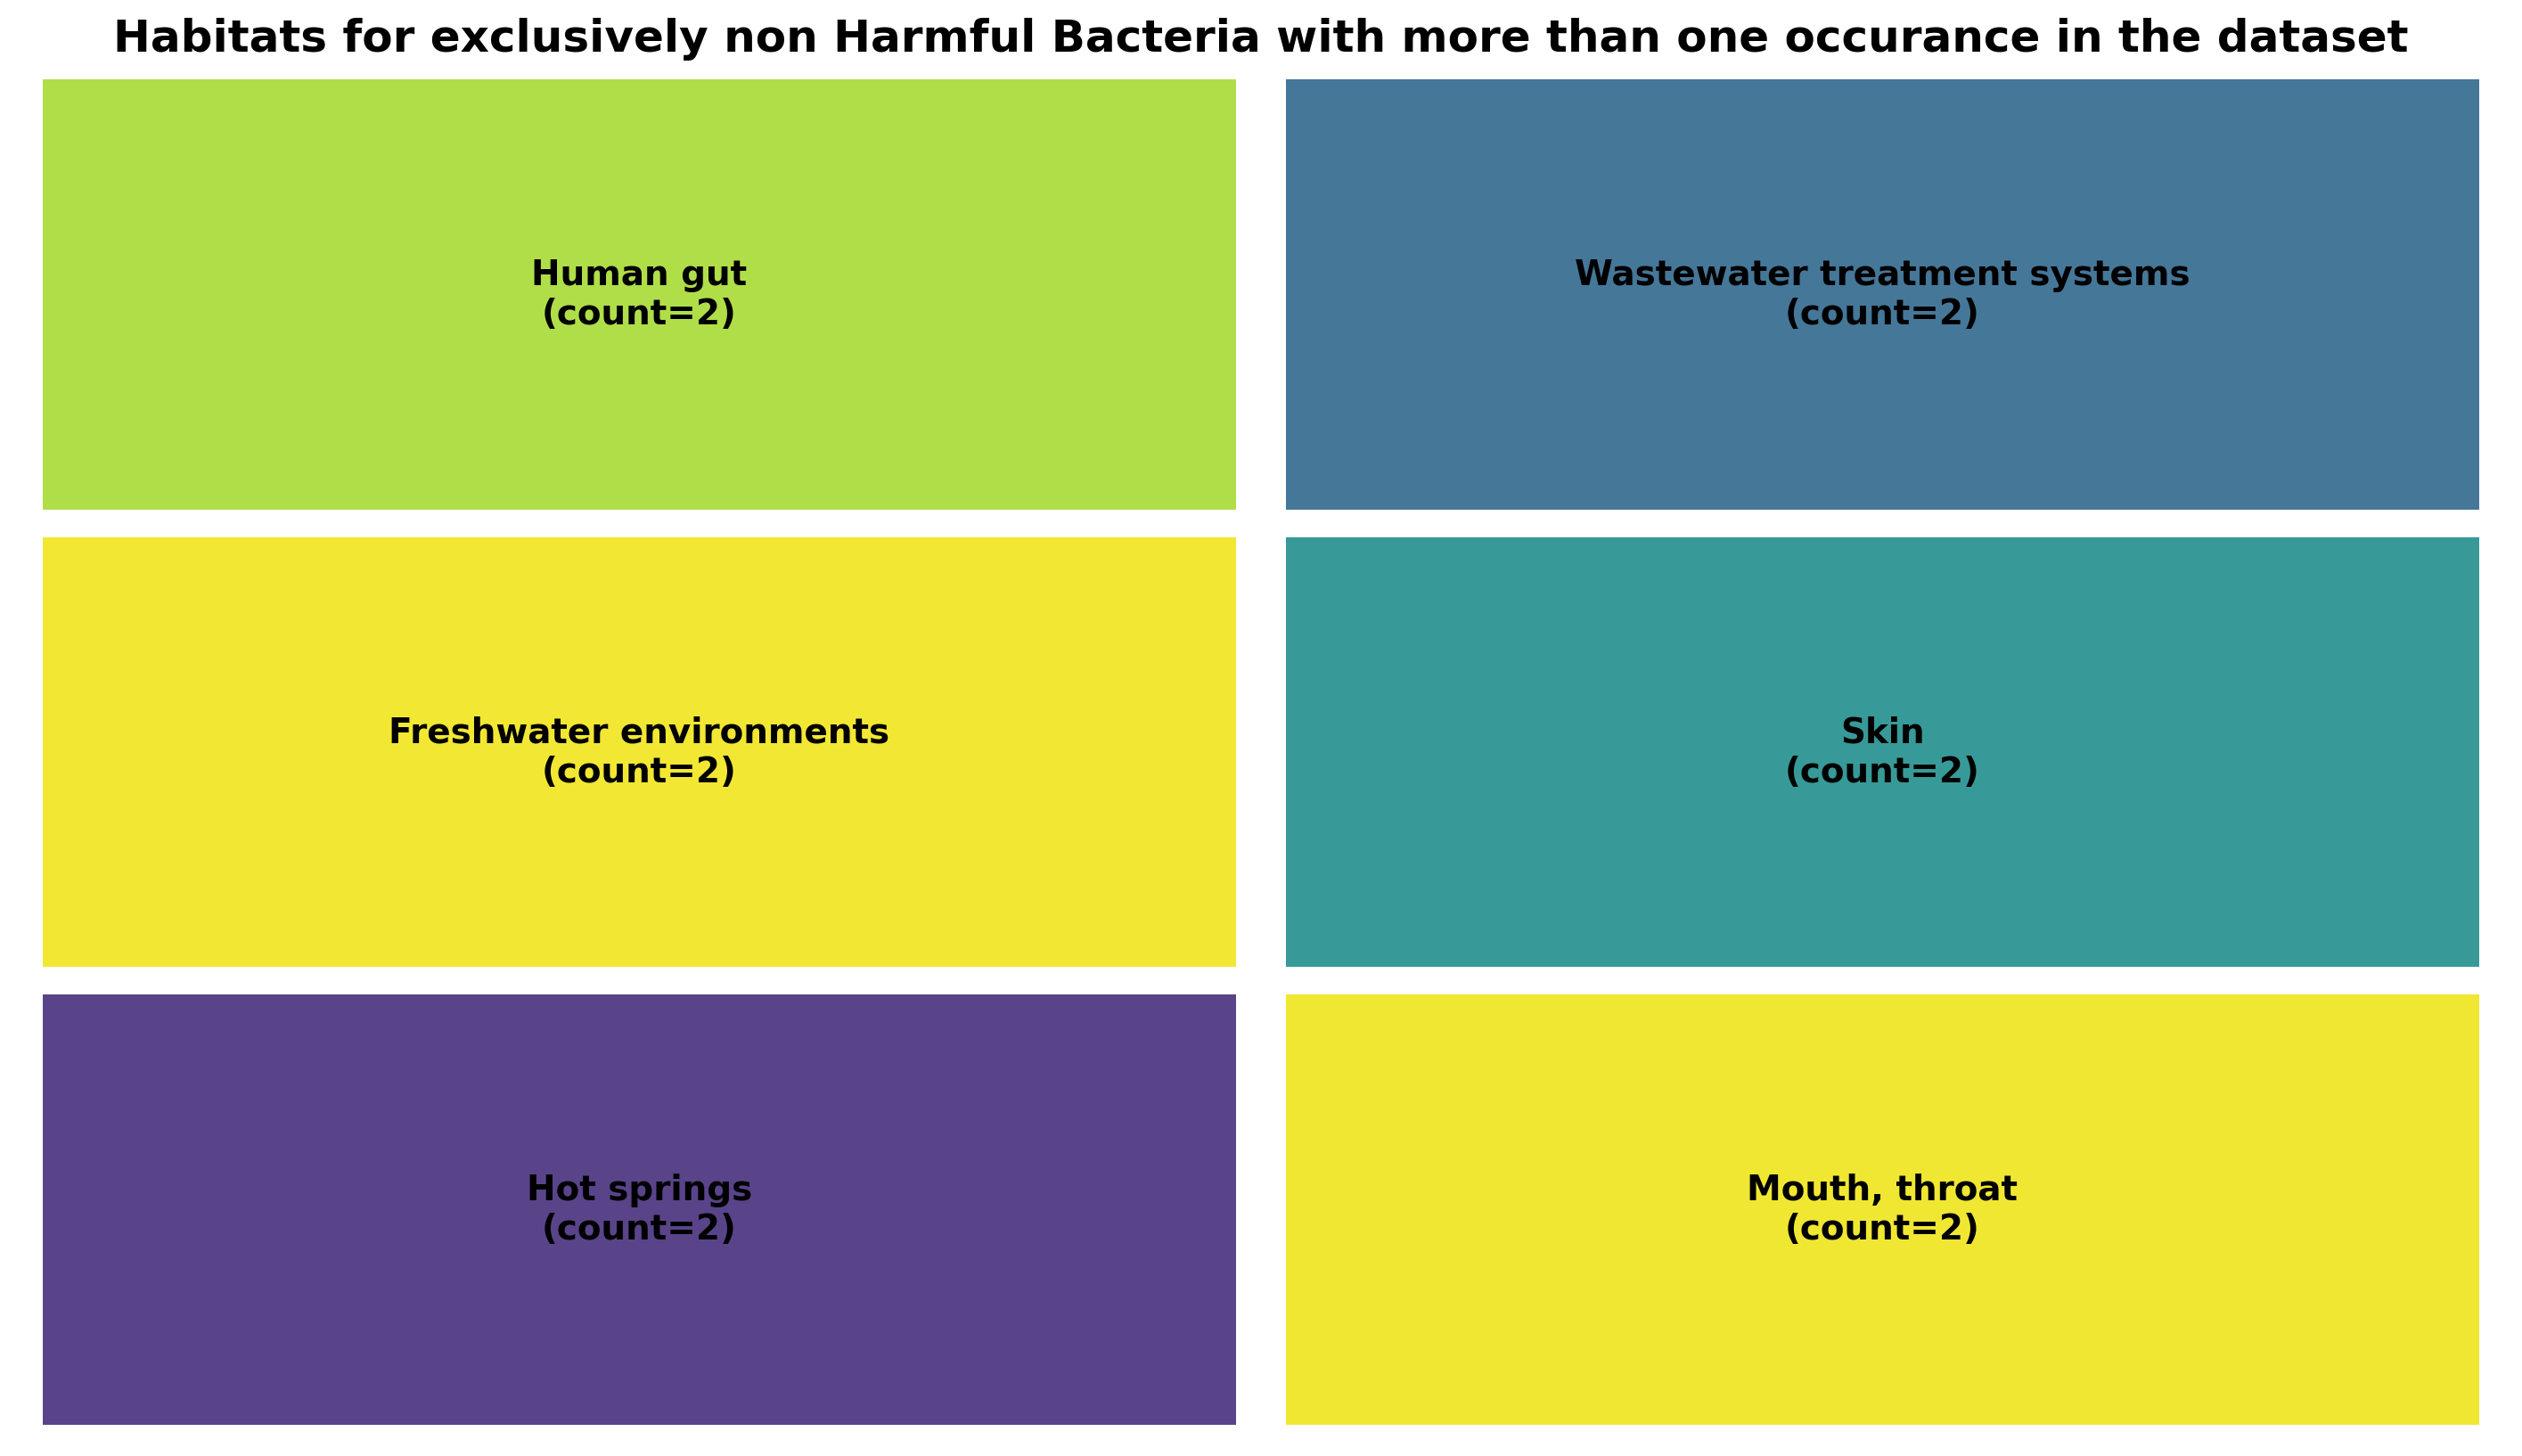

In [22]:
#habitats for exclusively non harmful bacteria on the human health with more than one occurance in the dataset
# Filter no harmful habitats
habitat_no_danger = habitat_stats_sorted[habitat_stats_sorted['percentage'] == 0]

# select ones with more than one occurance in the dataset
habitat_no_danger = habitat_no_danger[habitat_no_danger['total'] > 1]
print("Number of non harmful habitats with more than one occurance in the dataset:", habitat_no_danger.shape[0])

# Create labels
labels = habitat_no_danger.apply(
    lambda x: f"{x['Where Found']}\n(count={x['total']})",
    axis=1
)

# Plot
plt.figure(figsize=(18, 10), dpi=200)

squarify.plot(
    sizes=habitat_no_danger["total"],
    label=labels,
    alpha=0.9,
    text_kwargs={"fontsize": 14, "fontweight": "bold"},
    pad=True
)

plt.axis("off")
plt.title(
    "Habitats for exclusively non Harmful Bacteria with more than one occurance in the dataset",
    fontsize=18,
    fontweight="bold"
)

plt.show()

Number of partial harmful habitats in the dataset: 10


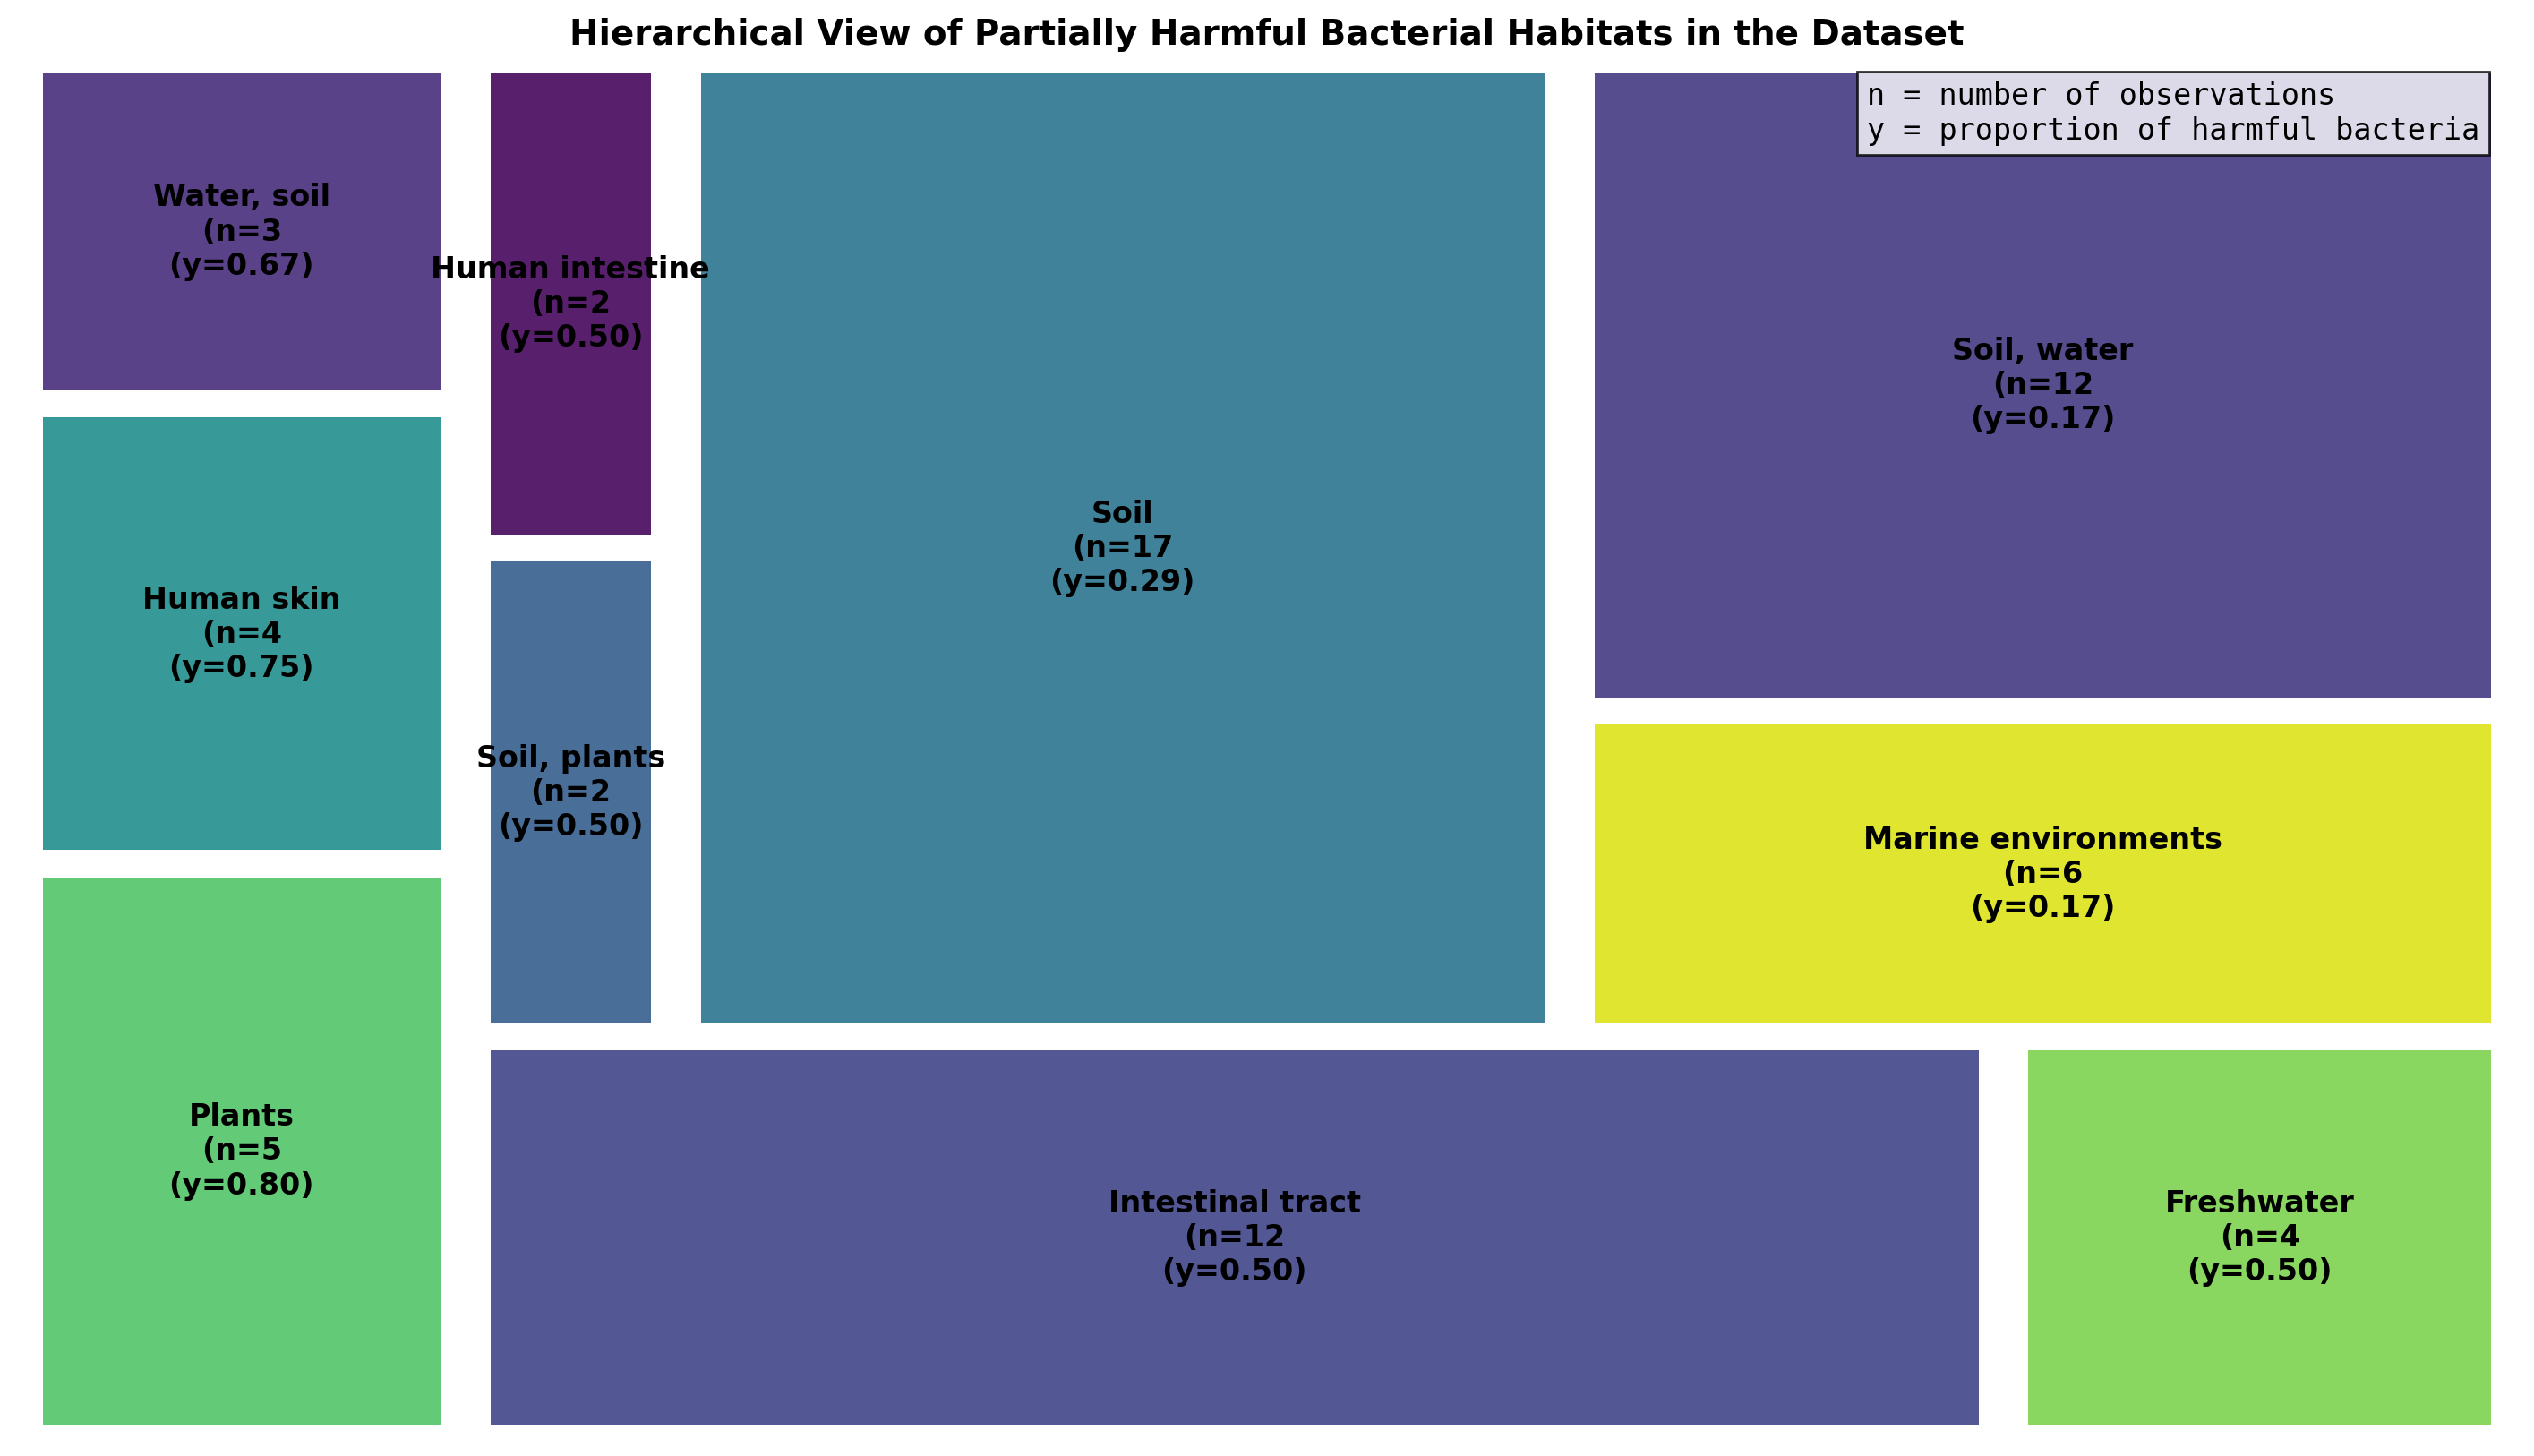

In [23]:
#habitats for partial harmful bacteria on the human health with more than one occurance in the dataset
# Filter habitats for partial harmful habitats
habitat_partial_danger = habitat_stats_sorted[(habitat_stats_sorted['percentage'] > 0) & (habitat_stats_sorted['percentage'] < 1)]

print("Number of partial harmful habitats in the dataset:", habitat_partial_danger.shape[0])

# Create labels
labels = habitat_partial_danger.apply(
    lambda x: f"{x['Where Found']}\n(n={x['total']}\n(y={x['percentage']:.2f})",
    axis=1
)

# Plot
plt.figure(figsize=(18, 10), dpi=200)

squarify.plot(
    sizes=habitat_partial_danger["total"],
    label=labels,
    alpha=0.9,
    text_kwargs={"fontsize": 12, "fontweight": "bold"},
    pad=True
)

plt.axis("off")
plt.title(
    "Hierarchical View of Partially Harmful Bacterial Habitats in the Dataset",
    fontsize=14,
    fontweight="bold"
)
plt.text(
    0.74, 0.984,
    "n = number of observations\n"
    "y = proportion of harmful bacteria",
    ha='left',
    va='top',
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.8),
    transform=plt.gca().transAxes,
    family='monospace'
)
plt.show()

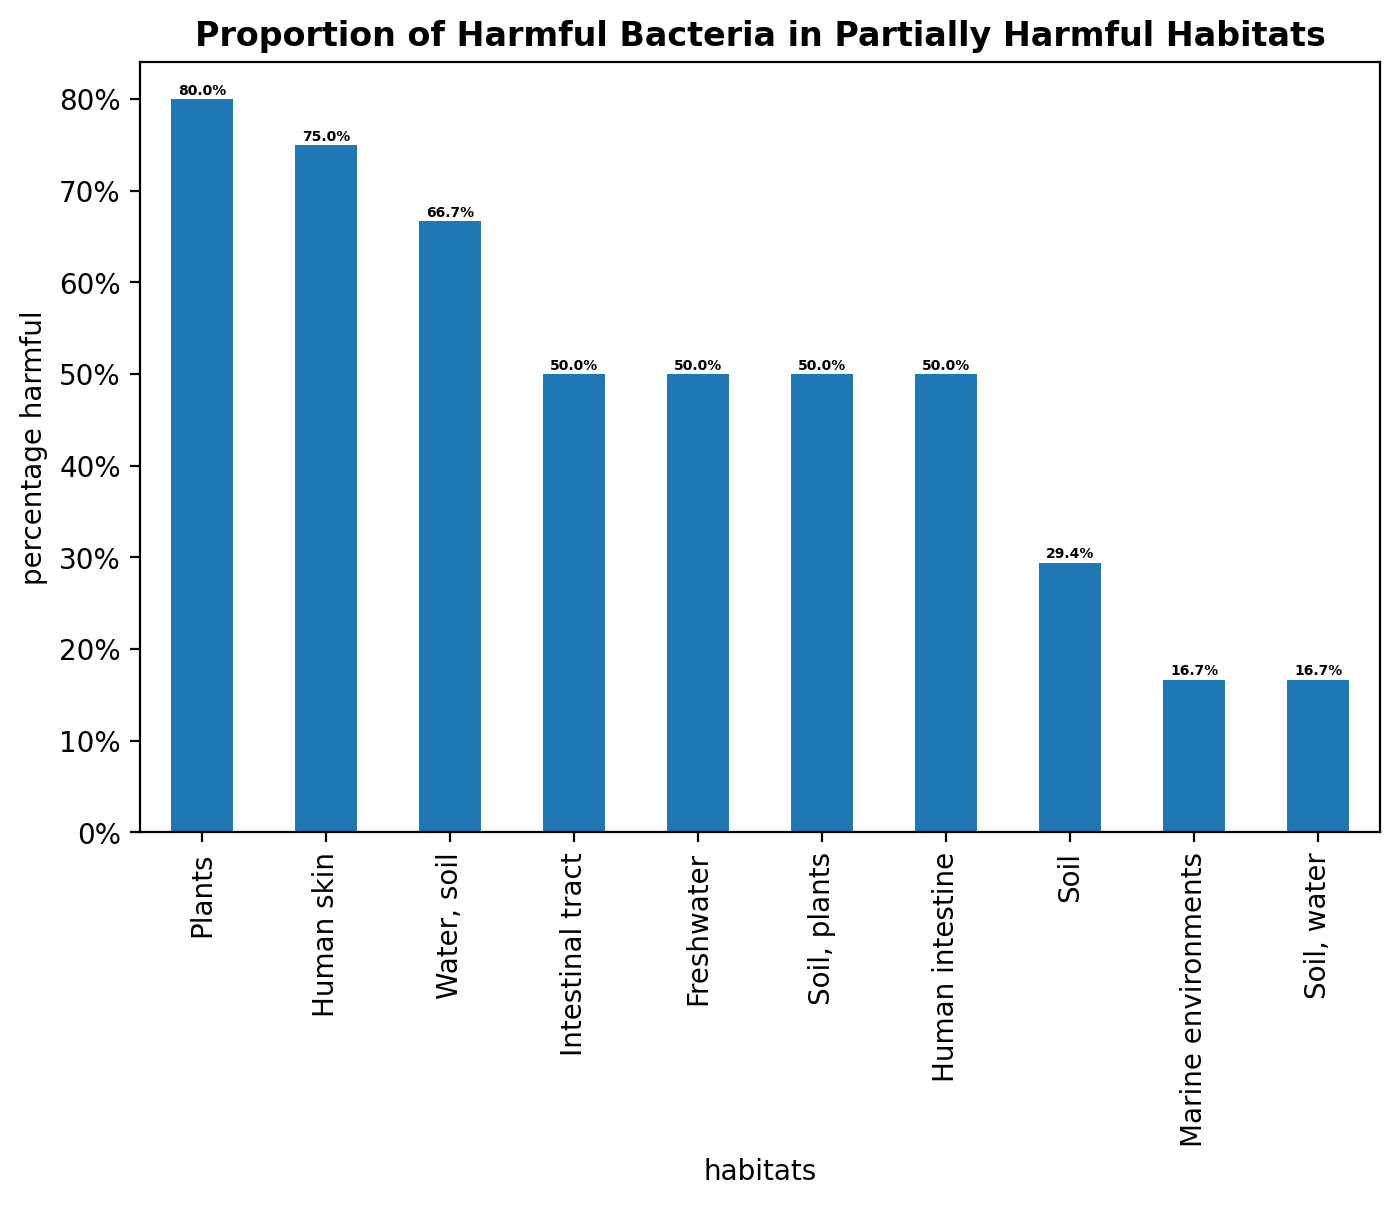

In [24]:
#habitats for partial harmful bacteria on the human health (visualization with bar plot)
habitat_partial_danger = habitat_partial_danger.set_index('Where Found')
fig, ax=plt.subplots(figsize=(8, 5), dpi=200)
habitat_partial_danger['percentage'].plot.bar(ax=ax)
ax.set_ylabel('percentage harmful')
ax.set_xlabel('habitats')
ax.set_yticklabels(['{:.0f}%'.format(x*100) for x in ax.get_yticks()]); 
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.1%}",
        ha='center',
        fontweight='bold',
        fontsize=5
    );
ax.set_title('Proportion of Harmful Bacteria in Partially Harmful Habitats', fontweight='bold')
plt.show()

In [25]:
#relationship between names of bacteria and the proportion of danger
name_stats = df.groupby(['Name']).agg(
    total=('Harmful to Humans', 'count'),
    harmful=('Harmful to Humans', lambda x: (x == 'Yes').sum())
)

name_stats['percentage'] = name_stats['harmful'] / name_stats['total']
name_stats.reset_index()

name_stats_sorted = name_stats.sort_values(by='percentage', ascending=False)
name_stats_sorted = name_stats_sorted.reset_index()
name_stats_sorted

,Name,total,harmful,percentage
0,Aeromonas hydrophila,1,1,1.0
1,Achromobacter xylosoxidans,1,1,1.0
2,Eikenella corrodens,1,1,1.0
3,Empedobacter brevis,1,1,1.0
4,Agrobacterium tumefaciens,1,1,1.0
...,...,...,...,...
189,Variovorax paradoxus,1,0,0.0
190,Xanthomonas campestris,1,0,0.0
191,Zooglea ramigera,1,0,0.0
192,Zoogloea ramigera,1,0,0.0


In [26]:
#bacteria with high danger on human health in the dataset
bacteria_danger_stats = name_stats_sorted[name_stats_sorted['percentage'] == 1]
bacteria_danger_stats

,Name,total,harmful,percentage
0,Aeromonas hydrophila,1,1,1.0
1,Achromobacter xylosoxidans,1,1,1.0
2,Eikenella corrodens,1,1,1.0
3,Empedobacter brevis,1,1,1.0
4,Agrobacterium tumefaciens,1,1,1.0
...,...,...,...,...
87,Stenotrophomonas maltophilia,1,1,1.0
88,Streptococcus agalactiae,1,1,1.0
89,Shigella dysenteriae,1,1,1.0
90,Q fever agent (Coxiella burnetii),1,1,1.0


In [27]:
#bacteria with no danger on human health in the dataset
bacteria_no_danger_stats = name_stats_sorted[name_stats_sorted['percentage'] == 0]
bacteria_no_danger_stats

,Name,total,harmful,percentage
93,Gemella haemolysans,1,0,0.0
94,Caldicellulosiruptor bescii,1,0,0.0
95,Brevundimonas diminuta,1,0,0.0
96,Caulobacter crescentus,1,0,0.0
97,Acetobacter pasteurianus,1,0,0.0
...,...,...,...,...
189,Variovorax paradoxus,1,0,0.0
190,Xanthomonas campestris,1,0,0.0
191,Zooglea ramigera,1,0,0.0
192,Zoogloea ramigera,1,0,0.0


In [28]:
#bacteria with partial danger depending on its habitat
bacteria_partial_danger = name_stats_sorted[(name_stats_sorted['percentage'] > 0) & (name_stats_sorted['percentage'] < 1)]
display(bacteria_partial_danger)
df_selected = df[df['Name'] == 'Fusobacterium nucleatum']
print('The danger of bacteria Fusobacterium nucleatum depends on its habitat.')
display(df_selected)

,Name,total,harmful,percentage
92,Fusobacterium nucleatum,2,1,0.5


The danger of bacteria Fusobacterium nucleatum depends on its habitat.


,Name,Family,Where Found,Harmful to Humans
43,Fusobacterium nucleatum,Fusobacteriaceae,"Mouth, throat",No
181,Fusobacterium nucleatum,Fusobacteriaceae,Human oral cavity,Yes


In [29]:
#write a function to determin if bacteria harmful or not harmful
def check_bacteria(name, df):
    """
    Determine whether a given bacteria is harmful to humans and display its details.

    Parameters
    ----------
    name : str
        The name of the bacteria to search for.
    df : pandas.DataFrame
        The dataset containing bacterial information. It must include the columns:
        'Name', 'Family', 'Where Found', and 'Harmful to Humans'.

    Returns
    -------
    str

    """
    # Clean input
    name = name.strip()
    
    # Find matches
    result = df[df['Name'].str.lower() == name.lower()]
    
    if result.empty:
        print("Bacteria not found in dataset")
        return ""
    
    # Remove duplicates (same bacteria repeated)
    result = result.drop_duplicates(subset=['Name', 'Family', 'Where Found'])
    
    print(f"\nResults for: {name}\n")
    
    for _, row in result.iterrows():
        harmful = "Harmful" if row['Harmful to Humans'] == 'Yes' else "Not Harmful"
        
        print(f"Bacteria: {row['Name']}")
        print(f"Family: {row['Family']}")
        print(f"Habitat: {row['Where Found']}")
        print(f"Status: {harmful}")
        print("-" * 40)
    return ""

display(check_bacteria('Fusobacterium nucleatum', df))


Results for: Fusobacterium nucleatum

Bacteria: Fusobacterium nucleatum
Family: Fusobacteriaceae
Habitat: Mouth, throat
Status: Not Harmful
----------------------------------------
Bacteria: Fusobacterium nucleatum
Family: Fusobacteriaceae
Habitat: Human oral cavity
Status: Harmful
----------------------------------------


''

In [30]:
#test the function check_bacteria
ipytest.autoconfig() # Konfiguriert ipytest mit sinnvollen Standardeinstellungen
#pytest
@pytest.fixture
def sample_df():
    '''generation of dataphram for testing'''
    data = {"Name": ["Fusobacterium nucleatum", "Fusobacterium nucleatum", "E.coli"],
            "Family": ["Fusobacteriaceae", "Fusobacteriaceae", "Enterobacteriaceae"],
            "Where Found": ["Mouth", "Human oral cavity", "Gut"],
            "Harmful to Humans": ["No", "Yes", "Yes"]}
    return pd.DataFrame(data)


def test_bacteria_found(sample_df, capsys):
    check_bacteria("Fusobacterium nucleatum", sample_df)
    
    captured = capsys.readouterr()
    
    assert "Results for: Fusobacterium nucleatum" in captured.out
    assert "Family: Fusobacteriaceae" in captured.out
    assert "Habitat: Mouth" in captured.out


def test_harmful_status(sample_df, capsys):
    check_bacteria("Fusobacterium nucleatum", sample_df)
    
    captured = capsys.readouterr()
    
    assert "Harmful" in captured.out
    assert "Not Harmful" in captured.out


def test_check_bacteria(capsys, sample_df):
    check_bacteria("Unknown bacteria", sample_df)
    
    captured = capsys.readouterr()
    
    assert "not found" in captured.out.lower()


def test_case_insensitive(sample_df, capsys):
    check_bacteria("fusobacterium nucleatum", sample_df)
    
    captured = capsys.readouterr()
    
    assert "Results for: fusobacterium nucleatum" in captured.out


def test_no_duplicate_rows(sample_df, capsys):
    check_bacteria("Fusobacterium nucleatum", sample_df)
    
    captured = capsys.readouterr()
    
    # Should appear exactly twice (two different habitats)
    assert captured.out.count("Bacteria: Fusobacterium nucleatum") == 2

ipytest.run('-vv')

======================================= test session starts =======================================
platform win32 -- Python 3.13.9, pytest-9.0.2, pluggy-1.6.0 -- c:\Users\yamen\Desktop\Weiterbildung\visual Studio Code\mein-project\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\yamen\Desktop\Weiterbildung\visual Studio Code\mein-project
configfile: pyproject.toml
collecting ... collected 5 items

t_448de0f24b6942fab4424c8d601fd0d9.py::test_bacteria_found PASSED                            [ 20%]
t_448de0f24b6942fab4424c8d601fd0d9.py::test_harmful_status PASSED                            [ 40%]
t_448de0f24b6942fab4424c8d601fd0d9.py::test_check_bacteria PASSED                            [ 60%]
t_448de0f24b6942fab4424c8d601fd0d9.py::test_case_insensitive PASSED                          [ 80%]
t_448de0f24b6942fab4424c8d601fd0d9.py::test_no_duplicate_rows PASSED                         [100%]

======================================== 5 passed in 0.08s ====================

<ExitCode.OK: 0>

In [31]:
# combination of bacterial families and habitats with more than one occurance in the dataset
# Prepare the data for treemap

treemap_data = df.groupby(["Family", "Where Found"]).size().reset_index(name = "Count")
treemap_data = treemap_data[treemap_data['Count'] > 1]

# PLot the TreeMap

plt.figure(figsize = (36, 30), dpi=400)
squarify.plot(sizes = treemap_data["Count"], label = treemap_data.apply(lambda x: f"{x['Family']} \n {x['Where Found']} \n count={x['Count']}", axis = 1), alpha = 0.8, text_kwargs = {"fontsize": 18, "fontweight": "bold"}, pad = True)
plt.axis("off")

plt.title("Hierarchical View of Combination of Bacterial Families and Habitats for more than One Occurance", fontsize = 25, color = "red", fontweight = "bold", y = 1.03);

In [32]:
# combination of bacterial families and habitats for dangerous families
# Prepare the data for treemap

treemap_family_habitat = df.groupby(["Family", "Where Found"]).agg(total=('Harmful to Humans', 'count'),
    harmful=('Harmful to Humans', lambda x: (x == 'Yes').sum()))

treemap_family_habitat['percentage'] = treemap_family_habitat['harmful'] / treemap_family_habitat['total']

treemap_family_habitat_danger = treemap_family_habitat[treemap_family_habitat['percentage'] == 1]

treemap_family_habitat_danger = treemap_family_habitat_danger[treemap_family_habitat_danger['total'] > 1]

treemap_family_habitat_danger = treemap_family_habitat_danger.reset_index()
print('Combination of bacterial families and habitats for dangerous families with more than one occurance in the dataset')
display(treemap_family_habitat_danger)
df_selected = df.merge(
    treemap_family_habitat_danger[['Family', 'Where Found']],
    on=['Family', 'Where Found'])
print('Names of bacteria involved by these families')
display(df_selected)

Combination of bacterial families and habitats for dangerous families with more than one occurance in the dataset


,Family,Where Found,total,harmful,percentage
0,Corynebacteriaceae,Plants,2,2,1.0
1,Coxiellaceae,Infected animals,2,2,1.0
2,Nocardiaceae,Soil,2,2,1.0


Names of bacteria involved by these families


,Name,Family,Where Found,Harmful to Humans
0,Coxiella burnetii,Coxiellaceae,Infected animals,Yes
1,Q fever agent (Coxiella burnetii),Coxiellaceae,Infected animals,Yes
2,Nocardia asteroides,Nocardiaceae,Soil,Yes
3,Clavibacter michiganensis,Corynebacteriaceae,Plants,Yes
4,Nocardia brasiliensis,Nocardiaceae,Soil,Yes
5,Curtobacterium flaccumfaciens,Corynebacteriaceae,Plants,Yes


In [33]:
# combination of bacterial families and habitats for non dangerous families
treemap_family_habitat_not_danger = treemap_family_habitat[treemap_family_habitat['percentage'] == 0]

treemap_family_habitat_not_danger = treemap_family_habitat_not_danger[treemap_family_habitat_not_danger['total'] > 1]

treemap_family_habitat_not_danger = treemap_family_habitat_not_danger.reset_index()
print('Combination of bacterial families and habitats for non dangerous families with more than one occurance in the dataset')
display(treemap_family_habitat_not_danger)
df_selected = df.merge(
    treemap_family_habitat_not_danger[['Family', 'Where Found']],
    on=['Family', 'Where Found'])
print('Names of bacteria involved by these families')
display(df_selected)


Combination of bacterial families and habitats for non dangerous families with more than one occurance in the dataset


,Family,Where Found,total,harmful,percentage
0,Bacillaceae,Soil,3,0,0.0
1,Bifidobacteriaceae,Intestinal tract,2,0,0.0
2,Sphingomonadaceae,"Soil, water",2,0,0.0
3,Zoogloeaceae,Wastewater treatment systems,2,0,0.0


Names of bacteria involved by these families


,Name,Family,Where Found,Harmful to Humans
0,Bacillus subtilis,Bacillaceae,Soil,No
1,Bifidobacterium bifidum,Bifidobacteriaceae,Intestinal tract,No
2,Bifidobacterium longum,Bifidobacteriaceae,Intestinal tract,No
3,Lysinibacillus sphaericus,Bacillaceae,Soil,No
4,Sphingomonas wittichii,Sphingomonadaceae,"Soil, water",No
5,Zooglea ramigera,Zoogloeaceae,Wastewater treatment systems,No
6,Zoogloea ramigera,Zoogloeaceae,Wastewater treatment systems,No
7,Brevibacillus brevis,Bacillaceae,Soil,No
8,Novosphingobium aromaticivorans,Sphingomonadaceae,"Soil, water",No


In [34]:
# combination of bacterial families and habitats for partial dangerous families
treemap_family_habitat_partial_danger = treemap_family_habitat[(treemap_family_habitat['percentage'] > 0)
                                                            & (treemap_family_habitat['percentage'] < 1)]


treemap_family_habitat_partial_danger = treemap_family_habitat_partial_danger.reset_index()
print('Combination of bacterial families and habitats for partial dangerous families')
display(treemap_family_habitat_partial_danger)
df_selected = df.merge(
    treemap_family_habitat_partial_danger[['Family', 'Where Found']],
    on=['Family', 'Where Found'])
print('Names of bacteria involved by these families')
display(df_selected)

Combination of bacterial families and habitats for partial dangerous families


,Family,Where Found,total,harmful,percentage
0,Enterobacteriaceae,Intestinal tract,8,4,0.5
1,Listeriaceae,"Soil, water",2,1,0.5
2,Micrococcaceae,Human skin,2,1,0.5
3,Xanthomonadaceae,Plants,2,1,0.5


Names of bacteria involved by these families


,Name,Family,Where Found,Harmful to Humans
0,Escherichia coli,Enterobacteriaceae,Intestinal tract,Yes
1,Salmonella enterica,Enterobacteriaceae,Intestinal tract,Yes
2,Listeria monocytogenes,Listeriaceae,"Soil, water",Yes
3,Shigella dysenteriae,Enterobacteriaceae,Intestinal tract,Yes
4,Proteus mirabilis,Enterobacteriaceae,Intestinal tract,No
5,Klebsiella oxytoca,Enterobacteriaceae,Intestinal tract,No
6,Xanthomonas campestris,Xanthomonadaceae,Plants,No
7,Yersinia enterocolitica,Enterobacteriaceae,Intestinal tract,Yes
8,Citrobacter freundii,Enterobacteriaceae,Intestinal tract,No
9,Enterobacter aerogenes,Enterobacteriaceae,Intestinal tract,No


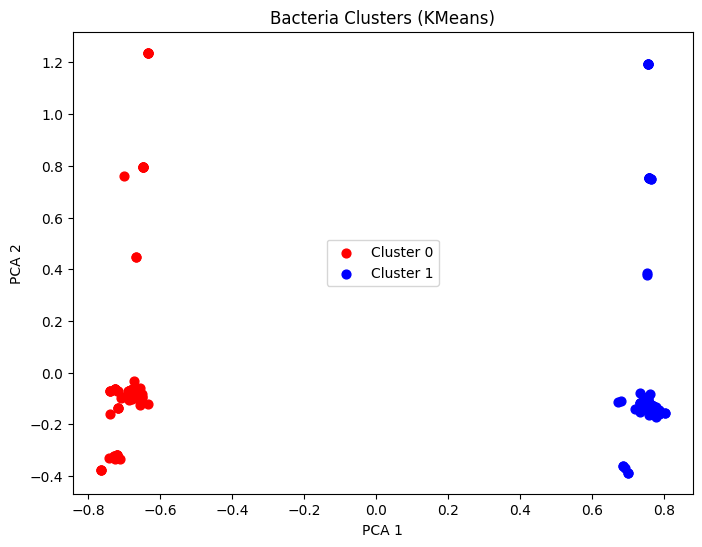

In [35]:
#clustering
features = df[['Family', 'Where Found', 'Harmful to Humans']]
#convert text to numbers
encoder = OneHotEncoder()
X = encoder.fit_transform(features)
#clustering with KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)
#visualization with PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(X.toarray())
colors = ['red', 'blue']
fig, ax = plt.subplots(figsize=(8, 6))
for cluster_id, color in enumerate(colors):
    ax.scatter(
        coords[df["Cluster"] == cluster_id, 0], 
        coords[df["Cluster"] == cluster_id, 1],
        s=40,
        color=color,
        label=f"Cluster {cluster_id}")
ax.set_title("Bacteria Clusters (KMeans)")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
legend = ax.legend(loc='center')
legend.set_alpha(0.005)

plt.show()


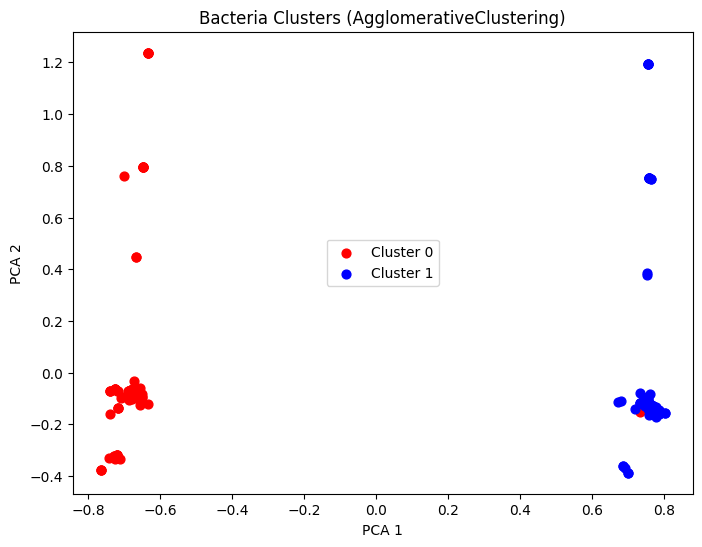

In [36]:
#clustering with AgglomerativeClustering
cluster_model = AgglomerativeClustering(n_clusters=2, linkage='ward')
clusters = cluster_model.fit_predict(X.toarray())

# Add cluster labels to the dataframe
df['Cluster'] = clusters
#visualization with PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(X.toarray())
colors = ['red', 'blue']
fig, ax = plt.subplots(figsize=(8, 6))
for cluster_id, color in enumerate(colors):
    ax.scatter(
        coords[df["Cluster"] == cluster_id, 0], 
        coords[df["Cluster"] == cluster_id, 1],
        s=40,
        color=color,
        label=f"Cluster {cluster_id}")
ax.set_title("Bacteria Clusters (AgglomerativeClustering)")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
legend = ax.legend(loc='center')
legend.set_alpha(0.005)

plt.show()


In [37]:
clustered_data = df.groupby('Cluster')[['Where Found', 'Harmful to Humans']].value_counts()
display(clustered_data)

Cluster  Where Found                          Harmful to Humans
0        Soil                                 No                   12
         Soil, water                          No                   10
         Intestinal tract                     No                    6
         Marine environments                  No                    5
         Freshwater                           No                    2
                                                                   ..
1        Water, fish                          Yes                   1
         Water, human clinical samples        Yes                   1
         Water, soil, human clinical samples  Yes                   1
         White-tailed deer                    Yes                   1
         Wild birds, domestic animals         Yes                   1
Name: count, Length: 130, dtype: int64

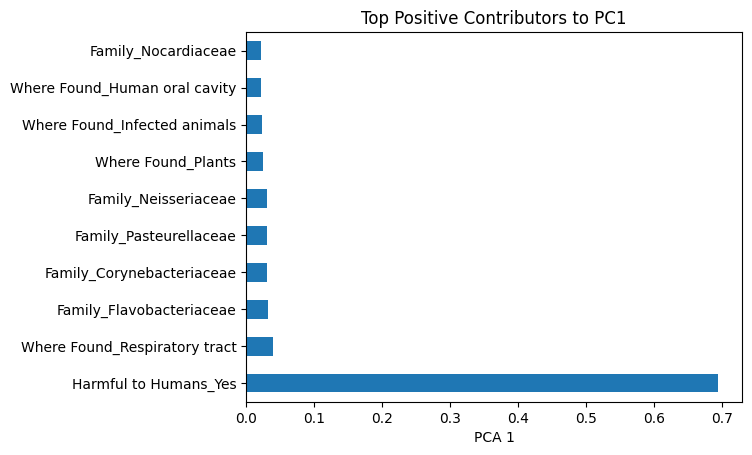

In [40]:
feature_names = encoder.get_feature_names_out()

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=["PC1", "PC2"])
pc1_top_pos = loadings["PC1"].sort_values(ascending=False).head(10)
pc2_top_pos = loadings["PC2"].sort_values(ascending=False).head(10)
pc1_top_neg = loadings["PC1"].sort_values(ascending=True).head(10)
pc2_top_neg = loadings["PC2"].sort_values(ascending=True).head(10)
# Top Positive Contributors to PC1
pc1_top_pos.plot(kind='barh');
plt.title("Top Positive Contributors to PC1");
plt.xlabel('PCA 1');

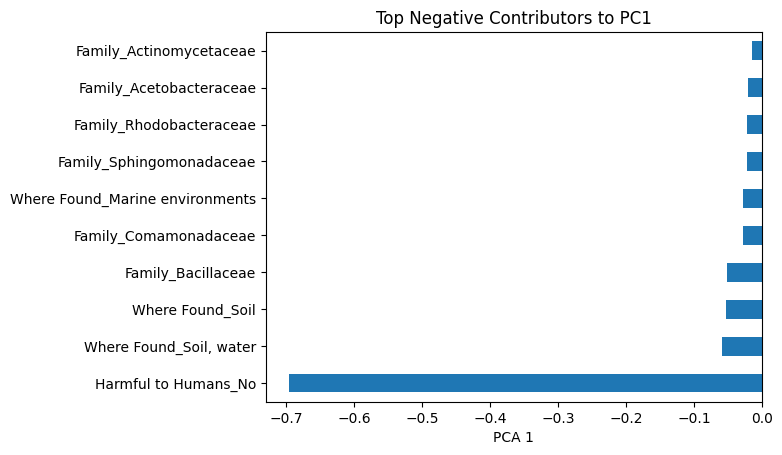

In [41]:
# Top Negative Contributors to PC1
pc1_top_neg.plot(kind='barh');
plt.title('Top Negative Contributors to PC1');
plt.xlabel('PCA 1');